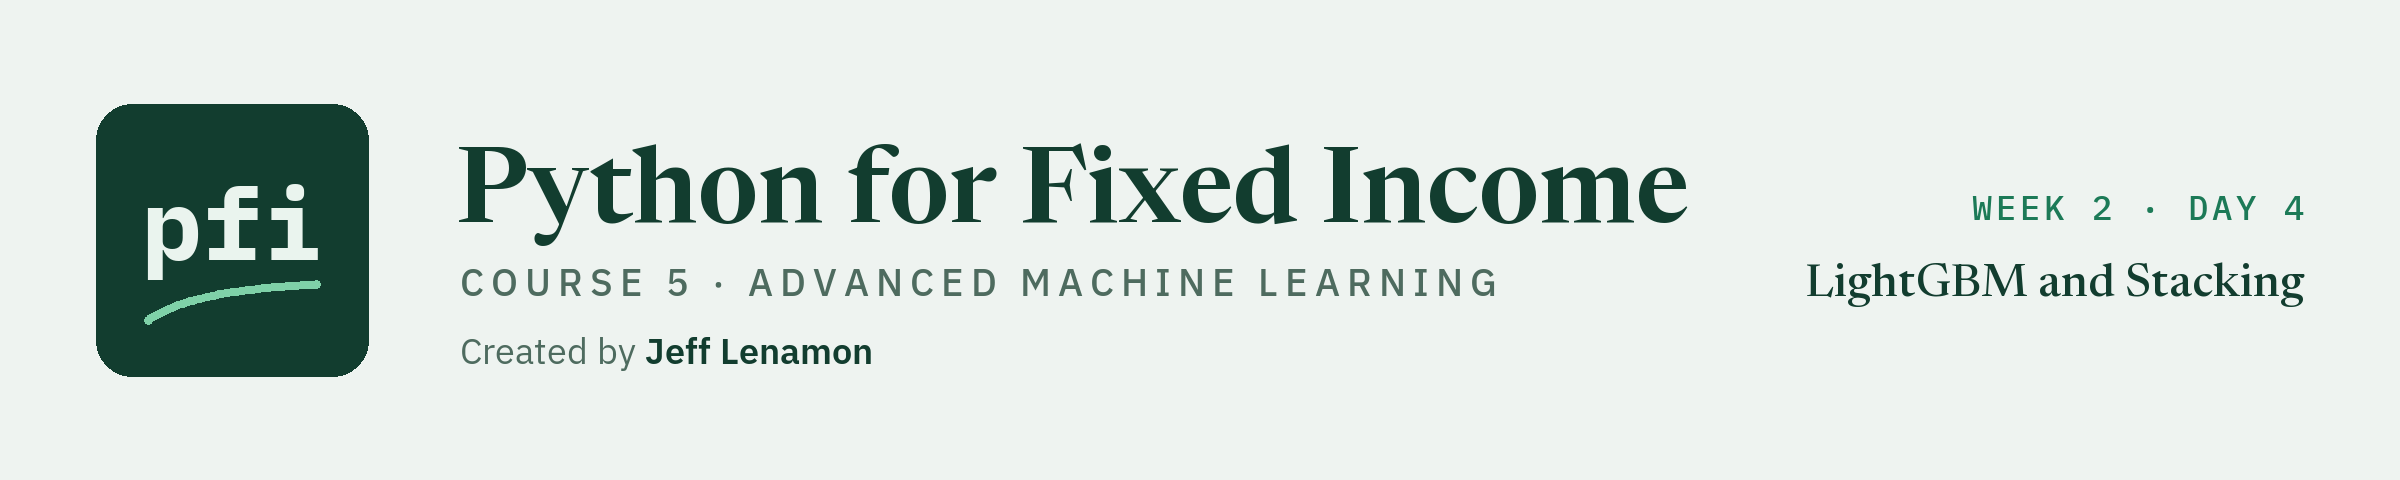

# LightGBM and Stacking

Week 2, Day 4. LightGBM grows its trees a different way and fits fast; a stack puts one model on top of others. Today: LightGBM on the card file beside the other boosters, and a stack built from out-of-fold outputs, measured against its best member.

**Data:** `credit_card_default.csv`, 30,000 card accounts in Taiwan in 2005: **real**, UCI Machine Learning Repository dataset 350, CC BY 4.0. Citation: Yeh, I. (2009). Default of Credit Card Clients [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C55S3H.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course5_advanced_ml/week2/day4/09_lightgbm_and_stacking.ipynb)

Day 8 fitted XGBoost. Today adds the third booster of the week, **LightGBM**, and scikit-learn's own fast booster, `HistGradientBoostingClassifier`, then asks what a desk asks when it has several models that score about the same: **can they be combined into one that does better than any of them?** The combining is called **stacking**: each model's output becomes a column, and a small model on top learns how much to trust each column. The trap is which outputs the top model learns from, and the module's one new function exists to avoid it.

**The card rules, as on every card day in this course.**

* **The data is real.** `credit_card_default.csv` holds 30,000 credit card accounts in Taiwan in 2005, with payment records from April to September and an outcome for the following month. Consumer credit there differs from US credit, and nothing here describes any other market.
* **People's attributes are never features.** `SEX`, `EDUCATION`, `MARRIAGE`, and `AGE` are in no model and no output is grouped by them. Every model today uses the other 19 columns.
* **Course 4's split, rebuilt.** 18,000 training rows fit, 6,000 validation rows report, and Course 4's 6,000 test rows stay closed (day 1, "The test-row rule"). The validation rows were used in Course 4 to choose, never to fit; Course 5 chooses nothing on them, so every setting today is compared inside the training rows.
* **A model's output is described, never acted on.** It is the model probability of default in this file, or a flag at a threshold; a model fitted with class weights gives the model's score. No output of either kind is a credit decision for any person.

Today you will:

1. Fit LightGBM and look inside its trees: a fixed number of leaves, not a fixed depth, and splits chosen from bins.
2. Score it on the validation rows beside Course 4's logistic regression.
3. See what `num_leaves` and `min_child_samples` do, by cross-validation inside the training rows.
4. Fit `HistGradientBoostingClassifier`, scikit-learn's own version of the same idea.
5. Put three boosters side by side on one validation set.
6. Build a stack by hand with `stack_inputs`: out-of-fold outputs as columns, a logistic regression on top.
7. Check that scikit-learn's `StackingClassifier` does exactly the same.
8. Ask whether the stack beats its best member, and report what the numbers say.

Q. Set up today's work folder: the thread settings, the seed, the data files, and the modules as day 8 left them.

In [1]:
# today's setup: the thread settings, the modules, the seed, the course data, and a fresh work folder
import os

# one thread for the maths libraries, so every run of the notebook gives the same last digits.
# These two lines must run before numpy, pandas, scikit-learn, XGBoost, or LightGBM is imported: if you ran another
# cell first, restart the kernel and run this cell first (in Colab: Runtime, Restart session).
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import importlib
import importlib.metadata
import importlib.util
import platform
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

# packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("sklearn", "scikit-learn"), ("statsmodels", "statsmodels"), ("scipy", "scipy"), ("xgboost", "xgboost"), ("lightgbm", "lightgbm"), ("imblearn", "imbalanced-learn"), ("shap", "shap"), ("pytest", "pytest")]:
    if importlib.util.find_spec(module_name) is None:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.")

import numpy as np
import pandas as pd

# the versions the saved outputs of this notebook came from (course5_advanced_ml/requirements.txt)
PINNED = {"numpy": "2.5.3", "pandas": "3.0.6", "scikit-learn": "1.9.1", "scipy": "1.18.1", "xgboost": "3.4.1", "lightgbm": "4.7.0", "imbalanced-learn": "0.14.2", "shap": "0.52.0", "matplotlib": "3.11.2", "pytest": "9.1.1"}
installed = {name: importlib.metadata.version(name) for name in PINNED}
print(f"Python {platform.python_version()}; " + ", ".join(f"{name} {version}" for name, version in installed.items()))
different = [name for name in PINNED if installed[name] != PINNED[name]]
if different:
    print(f"Not the course's pinned version: {', '.join(different)}. Printed numbers may differ in the last digits from the saved notebook.")

# the seed: one number for every random choice the course makes, so every run makes the same choices
SEED = 42

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "credit_card_default.csv").exists()

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course5_09_"))
os.chdir(work)

# 3. copy today's data files into the work folder
DATA_FILES = ["credit_card_default.csv", "benchmark.csv", "ratings.csv"]
for name in DATA_FILES:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES)}")
print(f"SEED = {SEED}")

Python 3.13.8; numpy 2.5.3, pandas 3.0.6, scikit-learn 1.9.1, scipy 1.18.1, xgboost 3.4.1, lightgbm 4.7.0, imbalanced-learn 0.14.2, shap 0.52.0, matplotlib 3.11.2, pytest 9.1.1
Work folder: pfi_course5_09_ysps30x6, in your temp folder
Data files from the data folder of the course repo: credit_card_default.csv, benchmark.csv, ratings.csv
SEED = 42


Q. Write `mlkit.py`, Course 4's complete module, unchanged. `ensemblekit` imports it.

In [2]:
%%writefile mlkit.py
"""mlkit: the small pieces of machine learning that scikit-learn leaves to the analyst, written down and tested.

Written day by day in Python for Fixed Income, Course 4: Machine Learning.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- Spreads are in basis points (bp). A model of log_oas is fitted in natural logs of bp; its errors are reported
  in bp after exp, and exp of a fitted log is a median-type value, not a mean.
- The positive class is 1 (default, bankrupt). Precision, recall, and F1 are for class 1 only.
- A row is flagged when its model probability is at least the threshold (probability >= threshold).
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart; the split
  functions here prove it with a check that stops.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from numpy.typing import ArrayLike  # a list, an array, or a pandas Series


def assert_disjoint(train_index: ArrayLike, test_index: ArrayLike) -> None:
    """Stop if any row label is in both the training rows and the test rows.

    Inputs: the labels (or positions) of the rows in each part, for example X_train.index and X_test.index.
    Output: None when the parts share no label.
    Convention: a row in both parts is a test row the model has already seen, which flatters every metric.
    Raises AssertionError naming how many labels are in both parts, and ValueError if either part is empty.
    """
    # the labels of each part as sets
    train = set(np.asarray(train_index).tolist())
    test = set(np.asarray(test_index).tolist())
    if not train or not test:
        raise ValueError("train_index and test_index must both hold at least one label")
    # the labels found in both parts
    shared = train & test
    if shared:
        raise AssertionError(f"{len(shared)} row labels are in both the training and the test rows")


def _as_1d_array(values: ArrayLike, name: str) -> np.ndarray:
    """Return `values` as a 1-D float array, or raise ValueError naming the input."""
    array = np.asarray(values, dtype=float)
    if array.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional, not {array.ndim}-dimensional")
    if array.size == 0:
        raise ValueError(f"{name} is empty")
    return array


def regression_metrics(y_true: ArrayLike, y_fitted: ArrayLike) -> dict[str, float]:
    """R-squared, mean absolute error, and root mean squared error of fitted values.

    Inputs: y_true and y_fitted, the same length, in the target's unit (for example oas in bp).
    Output: {"r2", "mae", "rmse"}. r2 is unitless, 1 - SS_res / SS_tot on the rows given (on test rows it can
    be negative); mae and rmse are in the target's unit. For a log_oas model, pass exp of both to get bp.
    Convention: equal to scikit-learn's r2_score, mean_absolute_error, and root_mean_squared_error.
    Excel: =RSQ(...) only for a straight line on one feature; =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)).
    Raises ValueError if the inputs are empty, not one-dimensional, or of different lengths.
    """
    # check both inputs and that they line up row for row
    actual = _as_1d_array(y_true, "y_true")
    fitted = _as_1d_array(y_fitted, "y_fitted")
    if actual.size != fitted.size:
        raise ValueError(f"y_true has {actual.size} values and y_fitted has {fitted.size}")
    # each error in the target's unit
    errors = actual - fitted
    # R-squared: the share of the spread around the mean that the fitted values account for
    ss_res = float(np.sum(errors ** 2))
    ss_tot = float(np.sum((actual - actual.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot
    # the average size of an error, and the square root of the average squared error
    mae = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors ** 2)))
    return {"r2": r2, "mae": mae, "rmse": rmse}


def adjusted_r2(r2: float, n_rows: int, n_features: int) -> float:
    """Adjusted R-squared: R-squared with a charge for each feature.

    Inputs: r2 on the training rows (unitless), n_rows the number of training rows, n_features the number of
    features not counting the intercept.
    Output: 1 - (1 - r2) x (n_rows - 1) / (n_rows - n_features - 1), unitless. An in-sample measure, so it is
    computed on training rows only.
    Excel: =1-(1-R2)*(n-1)/(n-k-1)
    Raises ValueError if n_features is negative or n_rows is not above n_features + 1.
    """
    # the formula needs at least one degree of freedom left after the features and the intercept
    if n_features < 0:
        raise ValueError(f"n_features must be 0 or more, not {n_features}")
    if n_rows <= n_features + 1:
        raise ValueError(f"n_rows ({n_rows}) must be greater than n_features + 1 ({n_features + 1})")
    # scale the unexplained share by the ratio of degrees of freedom
    return 1 - (1 - r2) * (n_rows - 1) / (n_rows - n_features - 1)


def rating_dummies(ratings: pd.Series, levels: list[str], reference: str) -> pd.DataFrame:
    """One indicator column per rating level except the reference level, which the intercept stands for.

    Inputs: ratings, one text rating per bond (for example "BBB+"); levels, every allowed level in the order the
    columns should follow (the rating column of ratings.csv, known in advance, not learned from the data);
    reference, the level left out.
    Output: a DataFrame with the same index, one float column (0.0 or 1.0) per level except reference, named
    rating_<level>, in the order of levels. A coefficient on rating_BB is then the difference from a bond rated
    `reference`, other features fixed.
    Convention: floats, not booleans, so every library and an Excel formula read the same 0.0 and 1.0. The
    reference is named by the caller, never chosen by alphabetical order.
    Raises ValueError if ratings is empty, reference is not in levels, or a rating is not in levels.
    """
    # check the inputs before building anything
    if len(ratings) == 0:
        raise ValueError("ratings is empty")
    if reference not in levels:
        raise ValueError(f"reference {reference!r} is not one of the levels")
    unknown = sorted(set(ratings) - set(levels))
    if unknown:
        raise ValueError(f"ratings not in levels: {unknown}")
    # one column per level, 1.0 where the bond has that rating
    columns = {f"rating_{level}": (ratings == level).astype(float) for level in levels if level != reference}
    return pd.DataFrame(columns, index=ratings.index)


def vif_table(X: pd.DataFrame) -> pd.Series:
    """Variance inflation factor of each feature: how much its coefficient's variance grows from the overlap with
    the other features.

    Input: X, the features as numeric columns (no constant column; one is added inside).
    Output: a Series named vif, one value per column, sorted from highest to lowest. VIF_j = 1 / (1 - R2_j),
    where R2_j is the R-squared of column j regressed on a constant and every other column. 1 means no overlap;
    above 5 is called high and above 10 very high, as conventions. A column that is an exact copy (or exact
    combination) of others has R2_j = 1 and VIF infinity.
    Convention: equal to statsmodels' variance_inflation_factor on X with a constant added.
    Excel: =1/(1-INDEX(LINEST(xj, other columns, TRUE, TRUE), 3, 1))
    Raises ValueError if X has fewer than two columns or fewer rows than columns plus two.
    """
    # check there is something to regress on, and enough rows to do it
    if X.shape[1] < 2:
        raise ValueError(f"X needs at least two columns, not {X.shape[1]}")
    if X.shape[0] < X.shape[1] + 2:
        raise ValueError(f"X has {X.shape[0]} rows, too few for {X.shape[1]} columns")
    values = X.to_numpy(dtype=float)
    result = {}
    for j, name in enumerate(X.columns):
        # column j is the target; a constant and the other columns are the features
        target = values[:, j]
        others = np.column_stack([np.ones(len(values)), np.delete(values, j, axis=1)])
        # least squares fit and its R-squared
        coefficients, *_ = np.linalg.lstsq(others, target, rcond=None)
        ss_res = float(np.sum((target - others @ coefficients) ** 2))
        ss_tot = float(np.sum((target - target.mean()) ** 2))
        r2 = 1 - ss_res / ss_tot
        # an exact combination of the others leaves no residual (R-squared 1 to the last digit): the VIF is infinite
        result[name] = np.inf if r2 >= 1 else 1 / (1 - r2)
    return pd.Series(result, name="vif").sort_values(ascending=False)


from scipy import stats  # Jarque-Bera and Shapiro-Wilk
from statsmodels.stats.diagnostic import het_breuschpagan  # Breusch-Pagan
from statsmodels.tools import add_constant  # the intercept column


def residual_tests(residuals: pd.Series, exog: pd.DataFrame) -> dict[str, float]:
    """p-values of three checks on a regression's residuals: constant variance and normality (two tests).

    Inputs: residuals, actual minus fitted on the training rows, in the target's unit; exog, the features the
    model was fitted on, without a constant (one is added inside), with the same rows.
    Output: {"breusch_pagan", "jarque_bera", "shapiro_wilk"}, each a p-value between 0 and 1. A small p-value
    (below 0.05, the course's convention) means the data would be surprising if the assumption held:
    - breusch_pagan: statsmodels het_breuschpagan with its default (Koenker's form, n x R-squared of the squared
      residuals regressed on a constant and exog); the assumption is constant variance;
    - jarque_bera: scipy.stats.jarque_bera (skew and kurtosis); the assumption is normal residuals;
    - shapiro_wilk: scipy.stats.shapiro; the assumption is normal residuals.
    Excel has no function for these; Breusch-Pagan can be built from LINEST and CHISQ.DIST.RT.
    Raises ValueError if the inputs are empty or have different numbers of rows.
    """
    # check the two inputs line up
    if len(residuals) == 0 or len(exog) == 0:
        raise ValueError("residuals and exog must not be empty")
    if len(residuals) != len(exog):
        raise ValueError(f"residuals has {len(residuals)} rows and exog has {len(exog)}")
    values = np.asarray(residuals, dtype=float)
    # Breusch-Pagan: returns the LM statistic, its p-value, then an F form; the LM p-value is kept
    _, bp_pvalue, _, _ = het_breuschpagan(values, add_constant(np.asarray(exog, dtype=float), has_constant="add"))
    # the two normality tests
    jb_pvalue = stats.jarque_bera(values).pvalue
    sw_pvalue = stats.shapiro(values).pvalue
    return {"breusch_pagan": float(bp_pvalue), "jarque_bera": float(jb_pvalue), "shapiro_wilk": float(sw_pvalue)}


from sklearn.pipeline import Pipeline  # the type of a chain of steps


def named_coefficients(pipeline: Pipeline) -> pd.Series:
    """The fitted coefficients of a pipeline's last step, labelled with the feature names that step saw.

    Input: a fitted scikit-learn Pipeline whose last step has coef_ (LinearRegression, Ridge, Lasso,
    LogisticRegression) and whose step before it has get_feature_names_out (a ColumnTransformer, a scaler).
    Output: a Series of coefficients indexed by feature name, in the order the model used them. Units: per unit
    of each feature as the model saw it, so per standard deviation after StandardScaler; the intercept is not
    included. For a binary LogisticRegression the one row of coef_ is used (log-odds of class 1).
    Raises ValueError if the last step has no coef_ (a tree, for example) or the pipeline has one step only.
    """
    # the model is the last step; the names come from everything before it
    if len(pipeline.steps) < 2:
        raise ValueError("the pipeline needs a preprocessing step before the model")
    model = pipeline.steps[-1][1]
    if not hasattr(model, "coef_"):
        raise ValueError(f"the last step, {type(model).__name__}, has no coef_")
    names = pipeline[:-1].get_feature_names_out()
    # a binary classifier keeps its coefficients in one row; flatten it
    coefficients = np.ravel(model.coef_)
    if coefficients.size != len(names):
        raise ValueError(f"{coefficients.size} coefficients but {len(names)} feature names")
    return pd.Series(coefficients, index=names, name="coefficient")


def odds_ratios(coefficients: pd.Series) -> pd.Series:
    """Odds ratios from logistic regression coefficients: exp of each coefficient, the intercept left out.

    Input: coefficients in log-odds, indexed by feature name, as statsmodels' Logit params (the intercept is
    named "const") or a Series with an entry named "intercept".
    Output: a Series of exp(coefficient) per feature: the factor by which the odds of class 1 multiply for one
    more unit of that feature, other features fixed. The unit is the feature's own (per 10,000 NT dollars if the
    feature was divided by 10,000; per standard deviation if it was scaled).
    Excel: =EXP(coef)
    Raises ValueError if no coefficient is left once the intercept is removed.
    """
    # leave out the intercept: exp of it is the odds when every feature is 0, not a ratio
    slopes = coefficients.drop(labels=["const", "intercept"], errors="ignore")
    if slopes.empty:
        raise ValueError("no coefficients left after removing the intercept")
    return np.exp(slopes).rename("odds_ratio")


def logistic_probability(z: float | ArrayLike) -> float | np.ndarray:
    """The logistic curve: turns log-odds z into a probability between 0 and 1.

    Input: z, a number or an array of numbers in log-odds (intercept plus coefficients times features).
    Output: 1 / (1 + exp(-z)), a float for a number, an array for an array. z = 0 gives 0.5.
    Excel: =1/(1+EXP(-z))
    """
    # numpy's exp works on a number and on an array alike
    probability = 1 / (1 + np.exp(-np.asarray(z, dtype=float)))
    return float(probability) if probability.ndim == 0 else probability


def _check_labels(y_true: ArrayLike, y_flag: ArrayLike) -> tuple[np.ndarray, np.ndarray]:
    """Return both inputs as integer arrays of 0 and 1, or raise ValueError."""
    actual = np.asarray(y_true)
    flagged = np.asarray(y_flag)
    if actual.ndim != 1 or flagged.ndim != 1 or actual.size == 0:
        raise ValueError("y_true and y_flag must be non-empty and one-dimensional")
    if actual.size != flagged.size:
        raise ValueError(f"y_true has {actual.size} values and y_flag has {flagged.size}")
    for name, values in (("y_true", actual), ("y_flag", flagged)):
        others = sorted(set(values.tolist()) - {0, 1})
        if others:
            raise ValueError(f"{name} holds labels other than 0 and 1: {others[:5]}")
    return actual.astype(int), flagged.astype(int)


def confusion_counts(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, int]:
    """The four cells of the confusion matrix, with 1 (default) as the positive class.

    Inputs: y_true, the actual outcome per row (0 or 1); y_flag, the model's flag per row (0 or 1), for example
    (probability >= threshold).
    Output: {"tn", "fp", "fn", "tp"} as whole numbers: true negatives (0 flagged 0), false positives (0 flagged
    1), false negatives (1 flagged 0), true positives (1 flagged 1). They add up to the number of rows.
    Convention: the same counts as confusion_matrix(y_true, y_flag).ravel() in scikit-learn.
    Excel: =COUNTIFS(actual,1,flag,1) and the other three combinations.
    Raises ValueError on labels other than 0 and 1, empty inputs, or inputs of different lengths.
    """
    actual, flagged = _check_labels(y_true, y_flag)
    # count each combination of actual and flag
    return {"tn": int(np.sum((actual == 0) & (flagged == 0))), "fp": int(np.sum((actual == 0) & (flagged == 1))),
            "fn": int(np.sum((actual == 1) & (flagged == 0))), "tp": int(np.sum((actual == 1) & (flagged == 1)))}


def classification_metrics(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, float]:
    """Accuracy, precision, recall, and F1 for class 1 (default), from 0/1 flags.

    Inputs: y_true and y_flag, as confusion_counts.
    Output: {"accuracy", "precision", "recall", "f1"}, each between 0 and 1:
    accuracy (TP + TN) / n; precision TP / (TP + FP), the share of flagged rows that are defaults; recall
    TP / (TP + FN), the share of defaults that are flagged; F1 their harmonic mean, 2TP / (2TP + FP + FN).
    Convention: pos_label=1, binary averaging, zero_division=0 (a model that flags nothing has precision 0, not
    an error), as scikit-learn's functions with those arguments.
    Excel: =TP/(TP+FP), =TP/(TP+FN) with the COUNTIFS cells.
    Raises ValueError as confusion_counts.
    """
    counts = confusion_counts(y_true, y_flag)
    tn, fp, fn, tp = counts["tn"], counts["fp"], counts["fn"], counts["tp"]
    # each ratio is 0 when its denominator is 0 (zero_division=0)
    accuracy = (tp + tn) / (tn + fp + fn + tp)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * tp / (2 * tp + fp + fn) if tp + fp + fn else 0.0
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}


def threshold_for_recall(y_true: ArrayLike, proba: ArrayLike, target_recall: float) -> float:
    """The highest threshold at which the model still catches at least `target_recall` of the defaults.

    Inputs: y_true, actual outcomes (0 or 1) on the rows used to choose (validation rows, or out-of-fold
    predictions on training rows, never test rows); proba, the model probability of class 1 per row;
    target_recall, the share of defaults the desk asks to catch, above 0 and at most 1.
    Output: one of the distinct probabilities. Flagging rows with probability >= that threshold gives recall at
    least target_recall, and the next higher distinct probability would give less. A higher threshold flags
    fewer rows, so this is the threshold with the fewest flags that meets the target.
    Convention: the course's threshold rule, stated as an illustration of the recall-against-precision choice.
    Raises ValueError if target_recall is not in (0, 1], the inputs differ in length, or there is no row of
    class 1.
    """
    # check the target and the inputs
    if not 0 < target_recall <= 1:
        raise ValueError(f"target_recall must be above 0 and at most 1, not {target_recall}")
    scores = _as_1d_array(proba, "proba")
    # y_true is checked as a set of 0/1 labels the same length as proba
    actual, _ = _check_labels(y_true, np.zeros(scores.size, dtype=int))
    positives = int(actual.sum())
    if positives == 0:
        raise ValueError("y_true has no row of class 1, so recall is undefined")
    # sort rows from the highest probability down; lowering the threshold adds rows in this order
    order = np.argsort(-scores, kind="stable")
    sorted_scores, sorted_actual = scores[order], actual[order]
    # defaults caught when every row down to this one is flagged
    caught = np.cumsum(sorted_actual)
    # a threshold equal to a probability flags every row with that probability, so look at the last row of
    # each run of equal probabilities
    last_of_run = np.append(sorted_scores[1:] != sorted_scores[:-1], True)
    recall = caught[last_of_run] / positives
    thresholds = sorted_scores[last_of_run]
    # thresholds run from high to low and recall only rises: take the first one that meets the target
    meets = np.nonzero(recall >= target_recall)[0]
    return float(thresholds[meets[0]])


from sklearn.model_selection import KFold, StratifiedKFold  # the course's cross-validation splitters


def cv_folds(kind: str = "classification") -> KFold | StratifiedKFold:
    """The course's cross-validation splitter, so the choice lives in one place.

    Input: kind, "classification" or "regression".
    Output: StratifiedKFold(5, shuffle=True, random_state=42) for classification (each fold keeps the share of
    class 1), KFold(5, shuffle=True, random_state=42) for regression. Pass it as cv= to GridSearchCV,
    cross_val_score, or cross_val_predict, on training rows only.
    Convention: never for dated rows, which use walk_forward_splits or TimeSeriesSplit (no shuffle).
    Raises ValueError for any other kind.
    """
    # five folds, shuffled once with the course's seed
    if kind == "classification":
        return StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    if kind == "regression":
        return KFold(n_splits=5, shuffle=True, random_state=42)
    raise ValueError(f'kind must be "classification" or "regression", not {kind!r}')


import re  # whole-word search

from sklearn.metrics import average_precision_score, roc_auc_score

# words that turn a description into a forecast, advice, or a lending decision; a reminder, not a proof
FORECAST_WORDS = ["will", "expect", "expects", "should", "forecast", "forecasts", "cheap", "rich", "attractive",
                  "signal", "signals", "buy", "sell", "approve", "decline", "lend", "invest"]


def compare_models(models: dict, X: pd.DataFrame, y: ArrayLike, thresholds: dict[str, float]) -> pd.DataFrame:
    """One row of metrics per fitted model, on the rows given.

    Inputs: models, {name: a fitted classifier with predict_proba}, fitted by the caller on training rows;
    X and y, the rows to report on (validation rows, or the test rows once at the end); thresholds,
    {name: threshold} for every model, chosen on rows other than these test rows.
    Output: a DataFrame indexed by model name with columns roc_auc and average_precision (from probabilities,
    no threshold), then threshold, accuracy, precision, recall, f1 for rows flagged at probability >= threshold.
    Convention: nothing is fitted here; an unfitted model raises scikit-learn's NotFittedError.
    Raises ValueError if models is empty or a model has no threshold.
    """
    # check every model has a threshold before computing anything
    if not models:
        raise ValueError("models is empty")
    missing = sorted(set(models) - set(thresholds))
    if missing:
        raise ValueError(f"no threshold for: {missing}")
    rows = {}
    for name, model in models.items():
        # the model probability of class 1 per row
        proba = model.predict_proba(X)[:, 1]
        # metrics that rank without a threshold, then metrics at the model's threshold
        row = {"roc_auc": roc_auc_score(y, proba), "average_precision": average_precision_score(y, proba),
               "threshold": thresholds[name]}
        row |= classification_metrics(y, (proba >= thresholds[name]).astype(int))
        rows[name] = row
    return pd.DataFrame.from_dict(rows, orient="index")


def assert_descriptive(text: str) -> None:
    """Stop if a written description uses a word from FORECAST_WORDS.

    Input: text, a description of what a model shows.
    Output: None if no listed word appears as a whole word, in any case.
    Convention: the list is a reminder, not a proof. A text can pass and still make a forecast in other words,
    and a listed word can be harmless in context; the check makes the writer look again.
    Raises ValueError naming every listed word found, in the order of FORECAST_WORDS.
    """
    # whole words only, ignoring case: "willing" does not match "will"
    found = [word for word in FORECAST_WORDS if re.search(rf"\b{word}\b", text, flags=re.IGNORECASE)]
    if found:
        raise ValueError(f"the text uses forecast, advice, or lending words: {found}")


def walk_forward_splits(dates: pd.DatetimeIndex, min_train: int, test_size: int,
                        gap: int = 0) -> list[tuple[np.ndarray, np.ndarray]]:
    """Expanding-window splits for dated rows: train on the past, test on the rows that follow.

    Inputs: dates, the rows' dates, unique and ascending; min_train, the rows in the first training window;
    test_size, the rows in each test window; gap, rows left out between the last training row and the first
    test row (use the number of rows a target or feature spans; 0 for a same-day target).
    Output: a list of (train_positions, test_positions), integer positions into dates. Fold k trains on
    positions 0 to min_train + k x test_size - 1 and tests the next test_size positions after `gap` rows.
    The window steps forward by test_size; a last test window shorter than test_size is dropped.
    Convention: never shuffled; every training date is before every test date.
    Raises ValueError if the dates are not unique and ascending, min_train or test_size is below 1, gap is
    negative, or there are too few rows for one fold.
    """
    # check the dates and the sizes
    index = pd.DatetimeIndex(dates)
    if not (index.is_unique and index.is_monotonic_increasing):
        raise ValueError("dates must be unique and ascending")
    if min_train < 1 or test_size < 1 or gap < 0:
        raise ValueError(f"need min_train >= 1, test_size >= 1, gap >= 0; got {min_train}, {test_size}, {gap}")
    splits = []
    train_end = min_train  # one past the last training position
    # add folds while a whole test window fits after the gap
    while train_end + gap + test_size <= len(index):
        test_start = train_end + gap
        splits.append((np.arange(0, train_end), np.arange(test_start, test_start + test_size)))
        train_end += test_size
    if not splits:
        raise ValueError(f"{len(index)} rows are too few for min_train {min_train}, gap {gap}, test_size {test_size}")
    return splits


def assert_past_only(train_dates: ArrayLike, test_dates: ArrayLike, gap: int = 0,
                     calendar: ArrayLike | None = None) -> None:
    """Stop unless every training date is earlier than every test date, with a gap where one is asked for.

    Inputs: the dates of the training rows and of the test rows; gap, the rows of `calendar` that must lie
    strictly between the last training date and the first test date; calendar, every date of the dataset
    (needed when gap is above 0).
    Output: None when the split uses only the past.
    Raises AssertionError naming the last training date and the first test date when the order or the gap is
    wrong, and ValueError if either part is empty or a gap is asked for without a calendar.
    """
    train = pd.DatetimeIndex(train_dates)
    test = pd.DatetimeIndex(test_dates)
    if len(train) == 0 or len(test) == 0:
        raise ValueError("train_dates and test_dates must both hold at least one date")
    # the latest training date must come before the earliest test date
    last_train, first_test = train.max(), test.min()
    if not last_train < first_test:
        raise AssertionError(f"a training date ({last_train.date()}) is not before the first test date "
                             f"({first_test.date()})")
    if gap > 0:
        if calendar is None:
            raise ValueError("a gap is counted in rows of the calendar, so calendar is needed")
        # rows of the calendar strictly between the two dates
        days = pd.DatetimeIndex(calendar)
        between = int(((days > last_train) & (days < first_test)).sum())
        if between < gap:
            raise AssertionError(f"only {between} rows lie between {last_train.date()} and {first_test.date()}, "
                                 f"fewer than the gap of {gap}")


from collections.abc import Iterable

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


def elbow_table(X: ArrayLike, k_values: Iterable[int], seed: int = 42) -> pd.DataFrame:
    """Inertia and silhouette of K-means for each number of clusters, to choose k by judgement.

    Inputs: X, the features already scaled (K-means measures distance, so units decide the clusters); k_values,
    the numbers of clusters to try, each 2 or more; seed, passed as random_state.
    Output: a DataFrame indexed by k (named k) with columns inertia (the within-cluster sum of squared distances,
    in squared scaled units; it falls as k rises) and silhouette (the mean silhouette coefficient, Euclidean,
    -1 to 1; higher means tighter, better separated clusters).
    Convention: KMeans(n_clusters=k, n_init=10, random_state=seed), n_init written out.
    Raises ValueError if k_values is empty, a k is below 2, or a k is not below the number of rows.
    """
    # check the k values before fitting
    ks = list(k_values)
    if not ks:
        raise ValueError("k_values is empty")
    n_rows = len(X)
    bad = [k for k in ks if k < 2 or k >= n_rows]
    if bad:
        raise ValueError(f"each k must be at least 2 and below the {n_rows} rows; not {bad}")
    rows = []
    for k in ks:
        # fit K-means with ten starts and the course's seed
        model = KMeans(n_clusters=k, n_init=10, random_state=seed).fit(X)
        rows.append({"k": k, "inertia": float(model.inertia_), "silhouette": float(silhouette_score(X, model.labels_))})
    return pd.DataFrame(rows).set_index("k")


def cluster_profile(frame: pd.DataFrame, labels: ArrayLike, columns: list[str]) -> pd.DataFrame:
    """Describe each cluster in the data's own units: how many rows, and the median of each column.

    Inputs: frame, the rows in their original units (oas in bp, duration in years), not the scaled features the
    clusters were fitted on; labels, the cluster of each row, in the same order; columns, the columns to profile.
    Output: a DataFrame indexed by cluster (named cluster, sorted), with count and one median column per name in
    columns, in the frame's units. A profile describes a group; it does not rank one.
    Excel: a pivot table counts and averages but has no median; =MEDIAN(IF(labels=k, column)) does.
    Raises ValueError if labels and frame differ in length, frame is empty, or a column is not in frame.
    """
    # check the inputs line up and the columns exist
    labels = np.asarray(labels)
    if len(frame) == 0:
        raise ValueError("frame is empty")
    if len(labels) != len(frame):
        raise ValueError(f"labels has {len(labels)} values and frame has {len(frame)} rows")
    missing = [c for c in columns if c not in frame.columns]
    if missing:
        raise ValueError(f"columns not in frame: {missing}")
    # group the original rows by cluster, then count and take medians
    grouped = frame[columns].groupby(pd.Series(labels, index=frame.index, name="cluster"))
    profile = grouped.median()
    profile.insert(0, "count", grouped.size())
    return profile.sort_index()


from sklearn.decomposition import PCA


def pca_loadings(pca: PCA, names: list[str]) -> pd.DataFrame:
    """The loadings of a fitted PCA, one column per component, each with a fixed sign.

    Inputs: pca, a fitted scikit-learn PCA; names, the input columns in the order the PCA saw them (for the
    curve, the tenors).
    Output: a DataFrame indexed by name with columns PC1, PC2, ...: each component's weights on the inputs
    (pca.components_ transposed, unit length). A component's sign is arbitrary, so each column is multiplied by
    -1 where needed to make its loadings sum to a positive number; a rerun or another library then gives the
    same picture. Scores that match these loadings are (X - pca.mean_) @ loadings.
    Excel: no PCA function; =MMULT(changes less their column means, loadings) gives the scores.
    Raises ValueError if names does not have one entry per input column.
    """
    # one name per input column
    components = np.asarray(pca.components_)
    if len(names) != components.shape[1]:
        raise ValueError(f"{len(names)} names for {components.shape[1]} input columns")
    loadings = pd.DataFrame(components.T, index=names,
                            columns=[f"PC{i}" for i in range(1, components.shape[0] + 1)])
    # flip each component whose loadings sum to a negative number
    signs = np.where(loadings.sum(axis=0) < 0, -1.0, 1.0)
    return loadings * signs


def explained_table(pca: PCA) -> pd.DataFrame:
    """The share of variance each component of a fitted PCA accounts for, and the running total, in percent.

    Input: pca, a fitted scikit-learn PCA.
    Output: a DataFrame indexed by PC1, PC2, ... with explained_pct (explained_variance_ratio_ x 100) and
    cumulative_pct (the running sum). With every component kept, the last cumulative_pct is 100.
    """
    # the ratios in percent, then their running sum
    explained = np.asarray(pca.explained_variance_ratio_) * 100
    index = [f"PC{i}" for i in range(1, len(explained) + 1)]
    return pd.DataFrame({"explained_pct": explained, "cumulative_pct": np.cumsum(explained)}, index=index)

Writing mlkit.py


Q. Write `ensemblekit.py` and `test_ensemblekit.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [3]:
%%writefile ensemblekit.py
"""ensemblekit: the pieces of ensembles, tuning, and rare-event modelling that the libraries leave to the analyst,
written down and tested.

Written day by day in Python for Fixed Income, Course 5: Advanced Machine Learning. It imports mlkit (Course 4's
module) and never changes it.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- The positive class is 1 (default, bankrupt). A row is flagged when its model output is at least the threshold.
- Course 5 never scores a row that Course 4 used as a test row. The course4_*_rows functions rebuild Course 4's
  splits exactly and return only the rows Course 5 may use; the closed rows are never returned.
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart.
- Every library call that can use more than one thread is given n_jobs=1, so every run gives the same digits.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from sklearn.model_selection import train_test_split  # Course 4's split, rebuilt

import mlkit  # Course 4's module: thresholds, metrics, splitters, and the no-leak check

# the card file: its outcome column and the 19 model columns (the four person columns are never features)
CARD_TARGET = "default payment next month"
CARD_FEATURES = ["LIMIT_BAL", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"] + \
    [f"BILL_AMT{i}" for i in range(1, 7)] + [f"PAY_AMT{i}" for i in range(1, 7)]


def course4_card_rows(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """Course 4's 60/20/20 split of the card file, rebuilt, without its test rows.

    Input: frame, the 30,000 accounts of credit_card_default.csv as read by pd.read_csv.
    Output: X_train (18,000 rows), X_valid (6,000 rows), y_train, y_valid, with the 19 model columns in
    CARD_FEATURES and the file's row labels. Course 4's 6,000 test rows are never returned.
    Convention: the same two calls as Course 4: train_test_split(test_size=0.2, stratify=y, random_state=42), then
    the remaining 80 percent split with test_size=0.25, stratified, same seed. The validation rows were used in
    Course 4 to choose a threshold and a pruning level, never to fit.
    Raises ValueError if a column is missing or the frame does not have 30,000 rows.
    """
    # check the frame is the whole card file
    missing = [name for name in CARD_FEATURES + [CARD_TARGET] if name not in frame.columns]
    if missing:
        raise ValueError(f"frame lacks the columns {missing}")
    if len(frame) != 30_000:
        raise ValueError(f"frame must hold the 30,000 card accounts, not {len(frame)}")
    X, y = frame[CARD_FEATURES], frame[CARD_TARGET]
    # Course 4's first cut puts 20 percent aside as test rows: they are dropped here, never returned
    X_rest, _, y_rest, _ = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    # Course 4's second cut: a quarter of the rest (20 percent of the file) as validation rows
    X_train, X_valid, y_train, y_valid = train_test_split(X_rest, y_rest, test_size=0.25, stratify=y_rest,
                                                          random_state=42)
    mlkit.assert_disjoint(X_train.index, X_valid.index)
    return X_train, X_valid, y_train, y_valid


def bootstrap_positions(n_rows: int, seed: int = 42) -> np.ndarray:
    """Draw n_rows row positions with replacement: one bootstrap sample.

    Input: n_rows, how many rows the data has (at least 1); seed, the random seed.
    Output: an array of n_rows positions from 0 to n_rows - 1, in the order drawn. A position can appear more than
    once, and some positions do not appear at all (about 36.8 percent of them for large n_rows).
    Convention: np.random.default_rng(seed).integers(0, n_rows, n_rows), so the same seed gives the same sample.
    Excel: =RANDBETWEEN(1,n) draws one position but takes no seed and changes at every recalculation.
    Raises ValueError if n_rows is below 1.
    """
    if n_rows < 1:
        raise ValueError(f"n_rows must be at least 1, not {n_rows}")
    # one generator per call, seeded, so the draw does not depend on anything drawn before
    rng = np.random.default_rng(seed)
    return rng.integers(0, n_rows, n_rows)


def out_of_bag(n_rows: int, drawn: np.ndarray) -> np.ndarray:
    """The positions a bootstrap sample never drew: its out-of-bag rows.

    Inputs: n_rows, how many rows the data has; drawn, the positions of a bootstrap sample.
    Output: the sorted positions from 0 to n_rows - 1 that are not in drawn.
    Convention: a model fitted on the drawn rows has never seen these rows, so they can score it.
    Raises ValueError if drawn is empty or holds a position outside 0 to n_rows - 1.
    """
    positions = np.asarray(drawn)
    if positions.size == 0:
        raise ValueError("drawn is empty")
    if positions.min() < 0 or positions.max() > n_rows - 1:
        raise ValueError(f"drawn holds a position outside 0 to {n_rows - 1}")
    # every position, minus the ones drawn at least once
    return np.setdiff1d(np.arange(n_rows), positions)


from sklearn.metrics import roc_auc_score  # ranking quality from probabilities


def bagged_proba(bagging, X: pd.DataFrame) -> np.ndarray:
    """Bagging by hand: the average of each fitted tree's class-1 probability, each on its own columns.

    Inputs: bagging, a fitted BaggingClassifier; X, the rows to score, with the columns it was fitted on.
    Output: one number per row, the mean over bagging.estimators_ of each tree's class-1 probability on the
    columns listed in bagging.estimators_features_. It equals bagging.predict_proba(X)[:, 1] within 1e-12.
    Convention: a tree whose bootstrap sample held only one class gives 0 for class 1 when that class is 0.
    Excel: with each tree's column of outputs pasted side by side, =AVERAGE(B2:K2) filled down.
    Raises ValueError if bagging is not fitted.
    """
    if not hasattr(bagging, "estimators_"):
        raise ValueError("bagging is not fitted: call fit first")
    # the trees were fitted on plain arrays of the chosen columns, so score them the same way
    values = np.asarray(X, dtype=float)
    total = np.zeros(len(values))
    for tree, columns in zip(bagging.estimators_, bagging.estimators_features_):
        proba = tree.predict_proba(values[:, columns])
        # the tree's classes are positions in bagging.classes_; class 1 is position 1
        position = np.flatnonzero(tree.classes_ == 1)
        total += proba[:, position[0]] if position.size else 0.0
    return total / len(bagging.estimators_)


def oob_auc(model, y_train) -> float:
    """ROC AUC of the out-of-bag probabilities of a bagged model or a random forest.

    Inputs: model, fitted with oob_score=True on the training rows; y_train, those rows' outcomes, in order.
    Output: roc_auc_score(y_train, model.oob_decision_function_[:, 1]): each row scored only by the trees that
    did not draw it.
    Convention: model.oob_score_ is the accuracy of the out-of-bag votes for a classifier, not ROC AUC; this
    function gives the ranking number the course compares models by.
    Raises ValueError if the model was fitted without oob_score=True, or if a row has no out-of-bag vote (too few
    trees, so some row was drawn by every tree).
    """
    if not hasattr(model, "oob_decision_function_"):
        raise ValueError("the model has no out-of-bag outputs: fit it with oob_score=True")
    proba = model.oob_decision_function_[:, 1]
    if np.isnan(proba).any():
        raise ValueError(f"{int(np.isnan(proba).sum())} rows have no out-of-bag vote: use more trees")
    return float(roc_auc_score(y_train, proba))


def tree_correlation(forest, X: pd.DataFrame) -> float:
    """How much the trees of an ensemble agree: the mean pairwise correlation of their class-1 outputs.

    Inputs: forest, a fitted random forest, extra-trees, or bagging model (anything with estimators_, and
    estimators_features_ for bagging); X, the rows to score (validation rows).
    Output: the mean of the upper triangle of np.corrcoef over the trees' class-1 probabilities on X: 1 means
    every tree gives the same ranking, 0 means no linear agreement.
    Convention: averaging trees removes less noise the more they agree; a random forest tries a random subset of
    columns at each split to lower this number.
    Excel: =CORREL(B2:B6001,C2:C6001) for one pair of pasted tree columns.
    Raises ValueError if the ensemble has fewer than two trees.
    """
    trees = list(forest.estimators_)
    if len(trees) < 2:
        raise ValueError(f"need at least two trees, the ensemble has {len(trees)}")
    # each tree was fitted on a plain array; bagging may give each tree its own columns
    values = np.asarray(X, dtype=float)
    columns = getattr(forest, "estimators_features_", [slice(None)] * len(trees))
    outputs = np.array([tree.predict_proba(values[:, cols])[:, -1] for tree, cols in zip(trees, columns)])
    # the correlation of every pair of trees, then the mean above the diagonal
    matrix = np.corrcoef(outputs)
    return float(matrix[np.triu_indices(len(trees), k=1)].mean())


from sklearn.inspection import permutation_importance  # the drop in a score when one column is shuffled


def importance_table(model, X_valid: pd.DataFrame, y_valid, scoring: str = "roc_auc", n_repeats: int = 5,
                     seed: int = 42) -> pd.DataFrame:
    """Two importance measures side by side: impurity importance and permutation importance.

    Inputs: model, a fitted tree ensemble with feature_importances_, fitted on a DataFrame; X_valid, y_valid,
    rows the model was NOT fitted on (validation rows); scoring, the score whose drop is measured; n_repeats, how
    many shuffles per column; seed, the random seed of the shuffles.
    Output: a DataFrame indexed by feature with columns impurity (model.feature_importances_, from the training
    rows, sums to 1), permutation (the mean drop in the score over n_repeats shuffles of that column),
    permutation_sd (their standard deviation), impurity_rank and permutation_rank (1 = largest), sorted by
    permutation, largest first.
    Convention: impurity importance is learned on the training rows and rewards columns the trees could split on
    to fit noise; permutation importance on unseen rows measures how much the score leans on a column there.
    Neither measure is a cause. permutation_importance runs with n_jobs=1.
    Raises ValueError if the model has no feature_importances_ (an unfitted model, or a linear model).
    """
    if not hasattr(model, "feature_importances_"):
        raise ValueError("the model has no feature_importances_: fit a tree ensemble first")
    # shuffle each column n_repeats times on the rows given and record the drop in the score
    result = permutation_importance(model, X_valid, y_valid, scoring=scoring, n_repeats=n_repeats,
                                    random_state=seed, n_jobs=1)
    table = pd.DataFrame({"impurity": model.feature_importances_, "permutation": result.importances_mean,
                          "permutation_sd": result.importances_std}, index=pd.Index(X_valid.columns, name="feature"))
    # rank 1 is the largest value; ties share the better rank
    table["impurity_rank"] = table["impurity"].rank(ascending=False, method="min").astype(int)
    table["permutation_rank"] = table["permutation"].rank(ascending=False, method="min").astype(int)
    return table.sort_values("permutation", ascending=False, kind="stable")


from sklearn.model_selection import cross_val_predict  # out-of-fold outputs, one per row


def course4_bench_rows(bench: pd.DataFrame, ratings: pd.DataFrame) -> pd.DataFrame:
    """Course 4's 615 training bonds of the synthetic benchmark, without its 206 test bonds.

    Inputs: bench, the 821 bonds of benchmark.csv; ratings, ratings.csv (rating and score).
    Output: the 615 training bonds with every column of bench plus score (the rating's number, 1 = AAA),
    log_oas (natural log of oas in bp), years (days from as_of_date to maturity / 365.25), and amount_bn
    (amount_outstanding in billions), with bench's row labels. Course 4's 206 test bonds are never returned.
    Convention: Course 4's split, train_test_split(test_size=0.25, random_state=42) on the joined rows. The bonds
    and their spreads are invented by the course's generator.
    Raises ValueError if bench does not hold 821 bonds.
    """
    if len(bench) != 821:
        raise ValueError(f"bench must hold the 821 benchmark bonds, not {len(bench)}")
    # the rating's number, joined row for row (each rating appears once in ratings)
    frame = bench.merge(ratings[["rating", "score"]], on="rating", how="left", validate="many_to_one")
    frame["log_oas"] = np.log(frame["oas"])
    dates = pd.to_datetime(frame["maturity"]) - pd.to_datetime(frame["as_of_date"])
    frame["years"] = dates.dt.days / 365.25
    frame["amount_bn"] = frame["amount_outstanding"] / 1e9
    # Course 4's split: the second part was its test set, dropped here
    train, _ = train_test_split(frame, test_size=0.25, random_state=42)
    return train


def oof_threshold(model, X, y, target_recall: float = 0.70, cv=None) -> tuple[float, np.ndarray]:
    """The course's threshold rule, applied to out-of-fold probabilities on the training rows.

    Inputs: model, an unfitted (or fitted) classifier with predict_proba; X, y, the training rows; target_recall,
    the share of defaults to catch; cv, a splitter (default mlkit.cv_folds(), stratified 5-fold, seed 42).
    Output: (threshold, proba): proba holds each training row's class-1 probability from the fold model that did
    not see it (cross_val_predict, n_jobs=1); threshold is mlkit.threshold_for_recall(y, proba, target_recall),
    the highest threshold whose out-of-fold recall is at least target_recall.
    Convention: the threshold is chosen on training rows only, so validation and test rows stay for reporting.
    cross_val_predict fits clones, so the caller's model is left as it was.
    Raises ValueError from mlkit.threshold_for_recall on a bad target or no row of class 1.
    """
    folds = cv if cv is not None else mlkit.cv_folds()
    proba = cross_val_predict(model, X, y, cv=folds, method="predict_proba", n_jobs=1)[:, 1]
    return mlkit.threshold_for_recall(y, proba, target_recall), proba


def samme_alpha(weighted_error: float, learning_rate: float = 1.0) -> float:
    """The weight AdaBoost gives one stump's vote, for two classes.

    Inputs: weighted_error, the stump's error with each row counted by its weight (above 0, below 0.5);
    learning_rate, the shrinkage AdaBoostClassifier applies (default 1.0).
    Output: learning_rate * ln((1 - e) / e), in natural logs. A stump right on 80 percent of the weight gets
    ln(4) = 1.3863; one barely better than a coin gets almost 0.
    Convention: the SAMME weight with two classes (its extra term ln(classes - 1) is ln 1 = 0); it equals
    AdaBoostClassifier's estimator_weights_.
    Excel: =LN((1-e)/e).
    Raises ValueError unless 0 < weighted_error < 0.5.
    """
    if not 0 < weighted_error < 0.5:
        raise ValueError(f"weighted_error must be above 0 and below 0.5, not {weighted_error}")
    return float(learning_rate * np.log((1 - weighted_error) / weighted_error))


def reweight(weights: np.ndarray, missed: np.ndarray, alpha: float) -> np.ndarray:
    """AdaBoost's new row weights after one round: the rows the stump missed count for more.

    Inputs: weights, the current row weights (non-negative); missed, 1 where the stump was wrong and 0 where it
    was right, the same length; alpha, the stump's weight (samme_alpha).
    Output: weights * exp(alpha * missed), divided by their sum so the new weights sum to 1.
    Excel: =w*EXP(alpha*miss) filled down, then each divided by the column's SUM.
    Raises ValueError if the lengths differ, the input is empty, or a weight is negative.
    """
    w = np.asarray(weights, dtype=float)
    m = np.asarray(missed, dtype=float)
    if w.size == 0 or w.shape != m.shape:
        raise ValueError(f"weights and missed must be non-empty and the same length, not {w.size} and {m.size}")
    if (w < 0).any():
        raise ValueError("weights must not be negative")
    # a missed row is multiplied by e^alpha, a correct row by 1
    new = w * np.exp(alpha * m)
    return new / new.sum()


from sklearn.tree import DecisionTreeRegressor  # one round's tree, fitted to the residuals


def boost_by_hand(X, y, n_rounds: int, learning_rate: float, max_depth: int, seed: int = 42) -> np.ndarray:
    """Gradient boosting for a squared error, by hand: start from the mean, then fit trees to the residuals.

    Inputs: X, the feature rows; y, the target (for example log_oas); n_rounds, how many trees; learning_rate,
    the fraction of each tree's output added; max_depth, each tree's depth; seed, each tree's random_state.
    Output: the fitted values on X after n_rounds: F0 = mean(y), then for each round
    F = F + learning_rate * tree.predict(X), with the tree fitted to the residuals y - F.
    Convention: equals GradientBoostingRegressor(n_estimators=n_rounds, learning_rate=..., max_depth=...,
    random_state=seed).predict(X) on the rows it was fitted on, within 1e-12. No criterion= is passed (scikit-learn
    1.9 deprecates "friedman_mse" for a regression tree).
    Excel: one round is =y-F, the two leaf means by AVERAGEIFS on either side of the stump's threshold, and
    =F+lr*IF(x<=t,left,right).
    Raises ValueError if n_rounds is below 1 or learning_rate is not positive.
    """
    if n_rounds < 1 or learning_rate <= 0:
        raise ValueError(f"n_rounds must be at least 1 and learning_rate positive, not {n_rounds}, {learning_rate}")
    target = np.asarray(y, dtype=float)
    # round 0: every row's fitted value is the mean
    fitted = np.full(target.size, target.mean())
    for _ in range(n_rounds):
        # fit a small tree to what is still unexplained, then add a fraction of it
        tree = DecisionTreeRegressor(max_depth=max_depth, random_state=seed).fit(X, target - fitted)
        fitted = fitted + learning_rate * tree.predict(X)
    return fitted


def mae_bp(log_true, log_fitted) -> float:
    """Mean absolute error in bp of a model fitted on log spreads.

    Inputs: log_true and log_fitted, natural logs of spreads in bp, the same length.
    Output: mean(|exp(log_true) - exp(log_fitted)|), in bp.
    Convention: the course's benchmark metric; exp of a fitted log is a median-type value, not a mean.
    Excel: =AVERAGE(ABS(EXP(a)-EXP(b))).
    Raises ValueError if the inputs are empty or of different lengths.
    """
    true, fitted = np.asarray(log_true, dtype=float), np.asarray(log_fitted, dtype=float)
    if true.size == 0 or true.shape != fitted.shape:
        raise ValueError(f"inputs must be non-empty and the same length, not {true.size} and {fitted.size}")
    return float(np.mean(np.abs(np.exp(true) - np.exp(fitted))))


def early_stopping_rows(X_train, y_train, fraction: float = 0.2, seed: int = 42) -> tuple:
    """Carve stopping rows out of the training rows, for early stopping, so no report row chooses the trees.

    Inputs: X_train, y_train, the training rows; fraction, the share set aside to stop on (above 0, below 0.5);
    seed, the split's seed.
    Output: X_fit, X_stop, y_fit, y_stop: a stratified split of the training rows only. Fit on X_fit and pass
    (X_stop, y_stop) as eval_set; validation and test rows are never an eval_set.
    Convention: train_test_split(test_size=fraction, stratify=y_train, random_state=seed), checked with
    mlkit.assert_disjoint.
    Raises ValueError unless 0 < fraction < 0.5.
    """
    if not 0 < fraction < 0.5:
        raise ValueError(f"fraction must be above 0 and below 0.5, not {fraction}")
    X_fit, X_stop, y_fit, y_stop = train_test_split(X_train, y_train, test_size=fraction, stratify=y_train,
                                                    random_state=seed)
    mlkit.assert_disjoint(X_fit.index, X_stop.index)
    return X_fit, X_stop, y_fit, y_stop


def scale_pos_weight(y) -> float:
    """XGBoost's weight for the rare class: negatives divided by positives.

    Input: y, the outcomes of the training rows (0 or 1).
    Output: (number of 0s) / (number of 1s). On Course 4's card training rows about 3.5.
    Convention: passed as XGBClassifier(scale_pos_weight=...); the model's output is then a score whose average
    is above the outcome rate, not a probability.
    Raises ValueError if y is empty or has no positive.
    """
    outcomes = np.asarray(y)
    positives = int((outcomes == 1).sum())
    if positives == 0:
        raise ValueError("y has no row of class 1")
    return float((outcomes == 0).sum() / positives)

Writing ensemblekit.py


In [4]:
%%writefile test_ensemblekit.py
"""Tests for ensemblekit.py.

Expected values come from scikit-learn, XGBoost, LightGBM, imbalanced-learn, or SHAP on the same inputs, from
Course 4's published numbers, or from small examples worked by hand. No test touches the network.
Run from this folder with:  python -m pytest
"""
from functools import cache
from pathlib import Path

import numpy as np
import pandas as pd
import pytest
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import ensemblekit

HERE = Path(__file__).resolve().parent
SEED = 42


@cache
def read_card() -> pd.DataFrame:
    """The 30,000 UCI card accounts, read once per test run."""
    return pd.read_csv(HERE / "credit_card_default.csv")


@cache
def card_rows() -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """Course 4's training and validation rows of the card file."""
    return ensemblekit.course4_card_rows(read_card())


def card_small(n: int = 3_000) -> tuple[pd.DataFrame, pd.Series]:
    """The first n of Course 4's training rows, for tests that fit many models and must stay fast."""
    X_train, _, y_train, _ = card_rows()
    return X_train.iloc[:n], y_train.iloc[:n]


def course4_card_test_labels() -> set:
    """The row labels of Course 4's card test set, recomputed with Course 4's own call."""
    card = read_card()
    y = card[ensemblekit.CARD_TARGET]
    _, X_test = train_test_split(card, test_size=0.2, stratify=y, random_state=SEED)
    return set(X_test.index)


def test_course4_card_rows_counts():
    X_train, X_valid, y_train, y_valid = card_rows()
    assert (len(X_train), len(X_valid), len(y_train), len(y_valid)) == (18_000, 6_000, 18_000, 6_000)
    assert list(X_train.columns) == ensemblekit.CARD_FEATURES
    for person in ("SEX", "EDUCATION", "MARRIAGE", "AGE", "ID"):
        assert person not in X_train.columns
    with pytest.raises(ValueError):
        ensemblekit.course4_card_rows(read_card().iloc[:100])


def test_course4_card_rows_closed_rows():
    X_train, X_valid, _, _ = card_rows()
    closed = course4_card_test_labels()
    assert len(closed) == 6_000
    assert not closed & set(X_train.index)
    assert not closed & set(X_valid.index)


def test_course4_card_rows_reproduces_logistic():
    X_train, X_valid, y_train, y_valid = card_rows()
    model = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))])
    model.fit(X_train, y_train)
    # Course 4 day 10's validation ROC AUC for the scaled logistic regression
    assert round(roc_auc_score(y_valid, model.predict_proba(X_valid)[:, 1]), 4) == 0.7190


def test_bootstrap_positions_with_replacement():
    drawn = ensemblekit.bootstrap_positions(1_000)
    assert drawn.shape == (1_000,)
    assert drawn.min() >= 0 and drawn.max() <= 999
    # with replacement: some rows twice, so fewer distinct positions than rows
    assert len(np.unique(drawn)) < 1_000
    with pytest.raises(ValueError):
        ensemblekit.bootstrap_positions(0)


def test_bootstrap_positions_seeded():
    first = ensemblekit.bootstrap_positions(500, seed=SEED)
    assert np.array_equal(first, ensemblekit.bootstrap_positions(500, seed=SEED))
    assert np.array_equal(first, np.random.default_rng(SEED).integers(0, 500, 500))
    assert not np.array_equal(first, ensemblekit.bootstrap_positions(500, seed=7))


def test_out_of_bag_hand():
    # rows 0 to 5; the sample drew 0, 0, 2, 5, 5, 5: rows 1, 3, 4 were never drawn
    left_out = ensemblekit.out_of_bag(6, np.array([0, 0, 2, 5, 5, 5]))
    assert left_out.tolist() == [1, 3, 4]
    with pytest.raises(ValueError):
        ensemblekit.out_of_bag(6, np.array([0, 6]))
    with pytest.raises(ValueError):
        ensemblekit.out_of_bag(6, np.array([], dtype=int))


def test_out_of_bag_share_near_e():
    n = 18_000
    drawn = ensemblekit.bootstrap_positions(n)
    left_out = ensemblekit.out_of_bag(n, drawn)
    # no row is both drawn and out of bag
    assert not set(left_out.tolist()) & set(drawn.tolist())
    # (1 - 1/n)^n tends to 1/e = 0.3679
    assert abs(len(left_out) / n - np.exp(-1)) < 0.01


from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier


def small_bagging(n_estimators: int = 10, oob: bool = False) -> tuple[BaggingClassifier, pd.DataFrame, pd.Series]:
    X, y = card_small()
    bagging = BaggingClassifier(DecisionTreeClassifier(random_state=SEED), n_estimators=n_estimators,
                                oob_score=oob, random_state=SEED, n_jobs=1)
    return bagging.fit(X, y), X, y


def test_bagged_proba_matches_sklearn():
    bagging, X, _ = small_bagging()
    _, X_valid, _, _ = card_rows()
    assert ensemblekit.bagged_proba(bagging, X_valid) == pytest.approx(bagging.predict_proba(X_valid)[:, 1], abs=1e-12)
    # also with a random half of the columns per tree, so estimators_features_ matters
    X, y = card_small()
    half = BaggingClassifier(DecisionTreeClassifier(random_state=SEED), n_estimators=10, max_features=0.5,
                             random_state=SEED, n_jobs=1).fit(X, y)
    assert ensemblekit.bagged_proba(half, X_valid) == pytest.approx(half.predict_proba(X_valid)[:, 1], abs=1e-12)


def test_bagged_proba_rejects_unfitted():
    with pytest.raises(ValueError, match="not fitted"):
        ensemblekit.bagged_proba(BaggingClassifier(random_state=SEED), card_small()[0])


def test_oob_auc_matches_roc_auc():
    bagging, _, y = small_bagging(n_estimators=40, oob=True)
    assert ensemblekit.oob_auc(bagging, y) == pytest.approx(roc_auc_score(y, bagging.oob_decision_function_[:, 1]),
                                                            abs=1e-12)
    # oob_score_ is accuracy, a different number
    assert ensemblekit.oob_auc(bagging, y) != pytest.approx(bagging.oob_score_, abs=1e-3)


def test_oob_auc_requires_oob_score():
    bagging, _, y = small_bagging()
    with pytest.raises(ValueError, match="oob_score=True"):
        ensemblekit.oob_auc(bagging, y)


from types import SimpleNamespace

from sklearn.ensemble import RandomForestClassifier


class StandInTree:
    """A stand-in for a fitted tree: its class-1 output is the first column plus a constant."""

    def __init__(self, shift: float):
        self.shift = shift

    def predict_proba(self, values: np.ndarray) -> np.ndarray:
        p = values[:, 0] / 10 + self.shift
        return np.column_stack([1 - p, p])


def test_tree_correlation_hand():
    X = pd.DataFrame({"a": [1.0, 2.0, 3.0, 4.0], "b": [0.0, 0.0, 1.0, 1.0]})
    # two outputs that differ by a constant are perfectly correlated
    forest = SimpleNamespace(estimators_=[StandInTree(0.1), StandInTree(0.3)])
    assert ensemblekit.tree_correlation(forest, X) == pytest.approx(1.0, abs=1e-12)


def test_tree_correlation_forest_below_bagging():
    X, y = card_small()
    _, X_valid, _, _ = card_rows()
    bagging = BaggingClassifier(DecisionTreeClassifier(random_state=SEED), n_estimators=10, random_state=SEED,
                                n_jobs=1).fit(X, y)
    forest = RandomForestClassifier(n_estimators=10, random_state=SEED, n_jobs=1).fit(X, y)
    assert forest.estimators_[0].max_features == "sqrt"
    assert ensemblekit.tree_correlation(forest, X_valid) < ensemblekit.tree_correlation(bagging, X_valid)


def test_tree_correlation_rejects_one_tree():
    X, y = card_small(500)
    forest = RandomForestClassifier(n_estimators=1, random_state=SEED, n_jobs=1).fit(X, y)
    with pytest.raises(ValueError, match="at least two trees"):
        ensemblekit.tree_correlation(forest, X)


from sklearn.inspection import permutation_importance


@cache
def forest_with_noise() -> tuple[RandomForestClassifier, pd.DataFrame, pd.Series]:
    """A 50-tree forest with 20-row leaves on 3,000 training rows plus a column of random numbers, and 2,000
    validation rows with their own random column."""
    X, y = card_small()
    _, X_valid, _, y_valid = card_rows()
    rng = np.random.default_rng(SEED)
    X = X.assign(noise=rng.normal(size=len(X)))
    X_valid = X_valid.iloc[:2_000].assign(noise=rng.normal(size=2_000))
    forest = RandomForestClassifier(n_estimators=50, min_samples_leaf=20, random_state=SEED, n_jobs=1).fit(X, y)
    return forest, X_valid, y_valid.iloc[:2_000]


def test_importance_table_columns_and_ranks():
    forest, X_valid, y_valid = forest_with_noise()
    table = ensemblekit.importance_table(forest, X_valid, y_valid)
    assert list(table.columns) == ["impurity", "permutation", "permutation_sd", "impurity_rank", "permutation_rank"]
    assert set(table.index) == set(X_valid.columns)
    assert table["impurity"].sum() == pytest.approx(1.0, abs=1e-12)
    assert table["permutation"].is_monotonic_decreasing
    assert table["permutation_rank"].iloc[0] == 1
    assert table.loc[table["impurity"].idxmax(), "impurity_rank"] == 1


def test_importance_table_matches_permutation_importance():
    forest, X_valid, y_valid = forest_with_noise()
    table = ensemblekit.importance_table(forest, X_valid, y_valid, n_repeats=3)
    direct = permutation_importance(forest, X_valid, y_valid, scoring="roc_auc", n_repeats=3, random_state=SEED,
                                    n_jobs=1)
    expected = pd.Series(direct.importances_mean, index=X_valid.columns)
    assert table["permutation"].to_numpy() == pytest.approx(expected[table.index].to_numpy(), abs=1e-12)


def test_importance_table_noise_near_zero():
    forest, X_valid, y_valid = forest_with_noise()
    table = ensemblekit.importance_table(forest, X_valid, y_valid)
    # on unseen rows, shuffling a column of random numbers costs (almost) nothing
    assert abs(table.loc["noise", "permutation"]) < 0.01
    assert table.loc["PAY_0", "permutation"] > 10 * abs(table.loc["noise", "permutation"])


def test_importance_table_rejects_model_without_importances():
    X, y = card_small(500)
    model = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))]).fit(X, y)
    with pytest.raises(ValueError, match="feature_importances_"):
        ensemblekit.importance_table(model, X, y)


from sklearn.exceptions import NotFittedError
from sklearn.utils.validation import check_is_fitted


@cache
def bench_rows() -> pd.DataFrame:
    """Course 4's 615 training bonds."""
    return ensemblekit.course4_bench_rows(pd.read_csv(HERE / "benchmark.csv"), pd.read_csv(HERE / "ratings.csv"))


def test_course4_bench_rows_counts_and_closed():
    train = bench_rows()
    assert len(train) == 615
    assert {"score", "log_oas", "years", "amount_bn"} <= set(train.columns)
    assert train["log_oas"].to_numpy() == pytest.approx(np.log(train["oas"]).to_numpy(), abs=1e-12)
    # Course 4's test bonds, recomputed with Course 4's call on the file
    bench = pd.read_csv(HERE / "benchmark.csv")
    _, bench_test = train_test_split(bench, test_size=0.25, random_state=SEED)
    assert len(bench_test) == 206
    assert not set(bench_test["cusip"]) & set(train["cusip"])
    with pytest.raises(ValueError):
        ensemblekit.course4_bench_rows(bench.iloc[:800], pd.read_csv(HERE / "ratings.csv"))


def test_oof_threshold_meets_recall():
    X, y = card_small()
    model = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))])
    threshold, proba = ensemblekit.oof_threshold(model, X, y, target_recall=0.70)
    assert proba.shape == (len(X),)
    flagged = proba >= threshold
    assert flagged[y.to_numpy() == 1].mean() >= 0.70
    # the next higher distinct probability would miss the target
    higher = np.unique(proba[proba > threshold])
    if higher.size:
        assert (proba >= higher[0])[y.to_numpy() == 1].mean() < 0.70


def test_oof_threshold_does_not_fit_callers_model():
    X, y = card_small(1_000)
    model = DecisionTreeClassifier(max_depth=3, random_state=SEED)
    ensemblekit.oof_threshold(model, X, y)
    with pytest.raises(NotFittedError):
        check_is_fitted(model)


from sklearn.ensemble import AdaBoostClassifier


def test_samme_alpha_hand():
    # right on 80 percent of the weight: ln(0.8 / 0.2) = ln 4
    assert ensemblekit.samme_alpha(0.2) == pytest.approx(np.log(4), abs=1e-12)
    assert ensemblekit.samme_alpha(0.2, learning_rate=0.5) == pytest.approx(0.5 * np.log(4), abs=1e-12)


def test_samme_alpha_rejects_error_at_half():
    for error in (0.5, 0.0, 0.7):
        with pytest.raises(ValueError):
            ensemblekit.samme_alpha(error)


def test_reweight_sums_to_one():
    new = ensemblekit.reweight(np.full(4, 0.25), np.array([1, 0, 0, 0]), np.log(3))
    # the missed row is multiplied by 3: weights 3, 1, 1, 1 over 6
    assert new == pytest.approx([0.5, 1 / 6, 1 / 6, 1 / 6], abs=1e-12)
    assert new.sum() == pytest.approx(1.0, abs=1e-12)
    with pytest.raises(ValueError):
        ensemblekit.reweight(np.array([0.5, -0.5]), np.array([1, 0]), 1.0)
    with pytest.raises(ValueError):
        ensemblekit.reweight(np.array([0.5, 0.5]), np.array([1, 0, 0]), 1.0)


def test_three_rounds_match_sklearn():
    X, y = card_small()
    ada = AdaBoostClassifier(DecisionTreeClassifier(max_depth=1, random_state=SEED), n_estimators=3,
                             random_state=SEED).fit(X, y)
    # three rounds by hand: fit a stump on the weights, measure its weighted error, weight it, reweight the rows
    weights = np.full(len(X), 1 / len(X))
    alphas = []
    for _ in range(3):
        stump = DecisionTreeClassifier(max_depth=1, random_state=SEED).fit(X, y, sample_weight=weights)
        missed = (stump.predict(X) != y.to_numpy()).astype(float)
        error = float(np.sum(weights * missed) / np.sum(weights))
        alphas.append(ensemblekit.samme_alpha(error))
        weights = ensemblekit.reweight(weights, missed, alphas[-1])
    assert alphas == pytest.approx(ada.estimator_weights_.tolist(), abs=1e-12)


from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor


def test_boost_by_hand_matches_sklearn():
    train = bench_rows()
    X, y = train[["score", "duration", "years"]], train["log_oas"]
    fitted = ensemblekit.boost_by_hand(X, y, n_rounds=100, learning_rate=0.1, max_depth=2)
    library = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=2, random_state=SEED).fit(X, y)
    assert fitted == pytest.approx(library.predict(X), abs=1e-12)


def test_boost_by_hand_one_round_is_mean_plus_stump():
    train = bench_rows()
    X, y = train[["score"]], train["log_oas"]
    fitted = ensemblekit.boost_by_hand(X, y, n_rounds=1, learning_rate=0.5, max_depth=1)
    stump = DecisionTreeRegressor(max_depth=1, random_state=SEED).fit(X, y - y.mean())
    assert fitted == pytest.approx(y.mean() + 0.5 * stump.predict(X), abs=1e-12)
    # a stump has two leaves, so one round gives two distinct fitted values
    assert len(np.unique(fitted.round(12))) == 2
    with pytest.raises(ValueError):
        ensemblekit.boost_by_hand(X, y, n_rounds=0, learning_rate=0.1, max_depth=1)


def test_mae_bp_hand():
    # spreads of 100 and 200 bp fitted at 110 and 180 bp: errors 10 and 20 bp
    log_true, log_fitted = np.log([100.0, 200.0]), np.log([110.0, 180.0])
    assert ensemblekit.mae_bp(log_true, log_fitted) == pytest.approx(15.0, abs=1e-9)
    with pytest.raises(ValueError):
        ensemblekit.mae_bp([1.0], [1.0, 2.0])


def test_early_stopping_rows_stratified_and_disjoint():
    X_train, X_valid, y_train, _ = card_rows()
    X_fit, X_stop, y_fit, y_stop = ensemblekit.early_stopping_rows(X_train, y_train)
    assert (len(X_fit), len(X_stop)) == (14_400, 3_600)
    assert not set(X_fit.index) & set(X_stop.index)
    # the stopping rows come from the training rows, never from the validation rows
    assert set(X_stop.index) <= set(X_train.index)
    assert not set(X_stop.index) & set(X_valid.index)
    assert abs(y_stop.mean() - y_train.mean()) < 0.001


def test_early_stopping_rows_rejects_fraction():
    X, y = card_small(500)
    for fraction in (0.0, 0.5, 0.8):
        with pytest.raises(ValueError):
            ensemblekit.early_stopping_rows(X, y, fraction=fraction)


def test_scale_pos_weight_hand():
    assert ensemblekit.scale_pos_weight([0, 0, 0, 1]) == pytest.approx(3.0, abs=1e-12)
    assert ensemblekit.scale_pos_weight(pd.Series([1, 0, 1, 0, 0, 0])) == pytest.approx(2.0, abs=1e-12)


def test_scale_pos_weight_rejects_no_positive():
    with pytest.raises(ValueError):
        ensemblekit.scale_pos_weight([0, 0, 0])

Writing test_ensemblekit.py


Q. Import the modules.

In [5]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import mlkit
import ensemblekit

# reload reads each file again, so that running this cell after a change picks up the change
importlib.reload(mlkit)
importlib.reload(ensemblekit)

# the functions and classes defined in ensemblekit itself, not the ones it imports, and not its helpers that start with _
functions = [name for name, obj in vars(ensemblekit).items()
             if callable(obj) and getattr(obj, "__module__", "") == "ensemblekit" and not name.startswith("_")]
print(f"ensemblekit functions: {functions}")

ensemblekit functions: ['course4_card_rows', 'bootstrap_positions', 'out_of_bag', 'bagged_proba', 'oob_auc', 'tree_correlation', 'importance_table', 'course4_bench_rows', 'oof_threshold', 'samme_alpha', 'reweight', 'boost_by_hand', 'mae_bp', 'early_stopping_rows', 'scale_pos_weight']


* The module starts the day with 32 tests behind it. Today adds one function and three tests.
* The setup copies the benchmark files as well as the card file, because the tests written on day 5 read them. Today's notebook does not use them.

## 9.1 LightGBM: Leaves, Not Depth, and Bins

LightGBM is gradient boosting, the idea of day 7: start from the average, fit a tree to what is still unexplained, add a fraction of it, repeat. Two things set it apart.

* **Leaf-wise growth.** A tree limited by depth splits every node at one level before going deeper; day 8's `max_depth=4` allows at most 16 leaves. LightGBM instead splits whichever leaf gains most, anywhere in the tree, until the tree has `num_leaves` leaves (31 by default). The tree can go deep where the rows reward it and stay shallow elsewhere.
* **Histograms.** Before fitting, LightGBM sorts each column's values into a small number of bins and only ever considers splits between bins, not between every pair of distinct values. That makes each split much faster to find.

Q. Load the card rows.

In [6]:
# the 30,000 UCI card accounts (real data, CC BY 4.0; the citation is under the title)
card = pd.read_csv("credit_card_default.csv")

# Course 4's split, rebuilt: training and validation rows only, with the 19 model columns
X_train, X_valid, y_train, y_valid = ensemblekit.course4_card_rows(card)
assert not set(X_train.columns) & {"SEX", "EDUCATION", "MARRIAGE", "AGE"}, "a person column is in the features"
print(f"training rows: {len(X_train):,}; validation rows: {len(X_valid):,}; features: {X_train.shape[1]}")

training rows: 18,000; validation rows: 6,000; features: 19


Q. Fit LightGBM on the training rows: 300 trees at a learning rate of 0.05, as day 8's XGBoost.

In [7]:
from lightgbm import LGBMClassifier

# n_jobs=1: one thread, so every run gives the same digits; verbose=-1: no log messages from the library
light = LGBMClassifier(n_estimators=300, learning_rate=0.05, random_state=SEED, n_jobs=1, verbose=-1)
light.fit(X_train, y_train)
print(f"fitted {light.n_estimators} trees, num_leaves {light.num_leaves}, learning rate {light.learning_rate}")

fitted 300 trees, num_leaves 31, learning rate 0.05


* `n_jobs=1` is written out, as on every booster in this course: LightGBM uses every core unless told otherwise. `verbose=-1` keeps it from printing its own log lines into the notebook.

Q. How many leaves does each tree have, and how deep do the trees go?

In [8]:
# every node of every tree, one row each; leaves have no split_feature
trees = light.booster_.trees_to_dataframe()
leaves = trees[trees["split_feature"].isna()]
leaves_per_tree = leaves.groupby("tree_index").size()
# node_depth counts the root as 1, so the questions on the way to the deepest leaf are one fewer
questions = leaves.groupby("tree_index")["node_depth"].max() - 1

print(f"trees: {trees['tree_index'].nunique()}; leaves per tree: {sorted(int(n) for n in leaves_per_tree.unique())}")
print(f"questions to the deepest leaf: {questions.min()} to {questions.max()} (first tree {questions.iloc[0]})")
first = trees.iloc[0]
print(f"first tree's first question: {first['split_feature']} <= {first['threshold']:g}")

trees: 300; leaves per tree: [31]
questions to the deepest leaf: 8 to 22 (first tree 8)
first tree's first question: PAY_0 <= 1.5


* Every one of the 300 trees has exactly 31 leaves, and their deepest leaves are 8 to 22 questions down. A tree that splits level by level needs a depth of 5 to hold 32 leaves; LightGBM's trees reach the same number of leaves by going deep along a few branches. That is leaf-wise growth, seen in the fitted model.
* The first question is `PAY_0 <= 1.5`, the repayment-status question day 1's trees asked first.

Q. How many split points does LightGBM use on a column with thousands of distinct values?

In [9]:
splits = trees[trees["split_feature"].notna()]
for column in ["LIMIT_BAL", "BILL_AMT1", "PAY_AMT1"]:
    distinct = X_train[column].nunique()
    used = splits.loc[splits["split_feature"] == column, "threshold"].nunique()
    print(f"{column}: {distinct:,} distinct values in the training rows; {used} distinct split points in 300 trees")

LIMIT_BAL: 78 distinct values in the training rows; 53 distinct split points in 300 trees
BILL_AMT1: 14,404 distinct values in the training rows; 207 distinct split points in 300 trees
PAY_AMT1: 5,717 distinct values in the training rows; 194 distinct split points in 300 trees


* `BILL_AMT1` holds 14,404 distinct values, but all 300 trees together split it at only 207 points. LightGBM puts each column into at most 255 bins by default (its `max_bin` setting), so it never weighs more than 254 split points on a column. A plain tree weighs a split between every pair of neighbouring values. The bins are where much of LightGBM's speed comes from, and on a column of bill amounts in dollars, a split point between two bins loses very little.

## 9.2 LightGBM on the Validation Rows

Q. Score LightGBM on the validation rows, beside Course 4's logistic regression.

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Course 4's logistic regression: scaled inside a pipeline, fitted on the training rows
logistic = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))]).fit(X_train, y_train)

# each model's probability of default on every validation account
proba_logistic = logistic.predict_proba(X_valid)[:, 1]
proba_light = light.predict_proba(X_valid)[:, 1]
for name, proba in [("logistic regression", proba_logistic), ("LightGBM", proba_light)]:
    print(f"{name}: validation ROC AUC {roc_auc_score(y_valid, proba):.4f}, "
          f"average precision {average_precision_score(y_valid, proba):.4f}")
print(f"LightGBM on its own training rows: ROC AUC {roc_auc_score(y_train, light.predict_proba(X_train)[:, 1]):.4f}")

logistic regression: validation ROC AUC 0.7190, average precision 0.4946
LightGBM: validation ROC AUC 0.7725, average precision 0.5434


LightGBM on its own training rows: ROC AUC 0.9220


**Rows.** Every model on the card file in this notebook is fitted on Course 4's 18,000 training rows and scored on Course 4's 6,000 validation rows, or scored by five-fold cross-validation inside the training rows where a cell says so; Course 4's 6,000 test rows are never scored in this course.

* Both outputs are the model probability of default in this file. LightGBM ranks the validation accounts at 0.7725, 0.0534 above Course 4's logistic regression (0.7190), with average precision 0.5434 against 0.4946.
* On its own training rows it scores 0.9220. That gap matters in section 9.6: a model's output on rows it was fitted on looks better than its output on rows it never saw.

> **STORY: the paper behind the name.** In 2017 a paper titled "LightGBM: A Highly Efficient Gradient Boosting Decision Tree" appeared in *Advances in Neural Information Processing Systems 30* (NIPS 2017), by Guolin Ke, Qi Meng, Thomas Finley, Taifeng Wang, Wei Chen, Weidong Ma, Qiwei Ye, and Tie-Yan Liu. Its title names the library this section fits, and the two words it leans on, "efficient" and "gradient boosting decision tree", are what sections 9.1 and 9.2 show: the same boosting as day 7, with trees grown and split in a faster way.
>
> Source (read 2026-10-05): the paper's page in the NeurIPS proceedings, https://papers.nips.cc/paper_files/paper/2017/hash/6449f44a102fde848669bdd9eb6b76fa-Abstract.html. Only the title, authors, proceedings volume, and year are taken from it; the paper itself was not read for this course.

## 9.3 num_leaves and min_child_samples

LightGBM's two main size settings are `num_leaves`, how many leaves each tree may have, and `min_child_samples`, how many training rows a leaf must hold at least (20 by default). More leaves let a tree say more; a larger minimum stops it from carving out tiny groups of rows.

Choosing among settings is a choice, so it is made inside the training rows, never on the validation rows. Each setting below is scored by five-fold cross-validation on the 18,000 training rows (`mlkit.cv_folds()`): fit on four fifths, score the fifth, five times, and average. Today nothing is chosen from the result; week 3 tunes properly.

Q. Score six values of `num_leaves` and four of `min_child_samples` by five-fold cross-validation, one setting changed at a time.

In [11]:
from sklearn.model_selection import cross_val_score

cv_rows = []
for setting, values in [("num_leaves", [4, 8, 16, 31, 63, 127]), ("min_child_samples", [5, 20, 100, 400])]:
    for value in values:
        model = LGBMClassifier(n_estimators=300, learning_rate=0.05, random_state=SEED, n_jobs=1, verbose=-1,
                               **{setting: value})
        # five ROC AUCs, one per held-out fifth of the training rows
        scores = cross_val_score(model, X_train, y_train, cv=mlkit.cv_folds(), scoring="roc_auc", n_jobs=1)
        cv_rows.append({"setting": setting, "value": value, "cv_mean": scores.mean(), "cv_sd": scores.std()})
cv_table = pd.DataFrame(cv_rows)
print(cv_table.round(4).to_string(index=False))

          setting  value  cv_mean  cv_sd
       num_leaves      4   0.7826 0.0030
       num_leaves      8   0.7819 0.0013
       num_leaves     16   0.7781 0.0025
       num_leaves     31   0.7745 0.0020
       num_leaves     63   0.7674 0.0026
       num_leaves    127   0.7608 0.0029
min_child_samples      5   0.7754 0.0024
min_child_samples     20   0.7745 0.0020
min_child_samples    100   0.7727 0.0026
min_child_samples    400   0.7750 0.0039


* With the defaults (31 leaves, 20 rows a leaf) the cross-validated ROC AUC is 0.7745, with a fold standard deviation of 0.0020.
* **Fewer leaves do better on these rows.** The score falls at every step from 4 leaves (0.7826, 0.0081 above the default) to 127 leaves (0.7608). Small trees suit a file whose strongest columns, the repayment statuses, need few questions.
* **The leaf minimum barely matters here.** The four values of `min_child_samples` span 0.0027, less than one fold standard deviation, with no steady direction.
* LightGBM's defaults are a starting point, not a setting tuned for this file. Week 3 searches both settings together and reports the result honestly.

Q. Draw both curves.

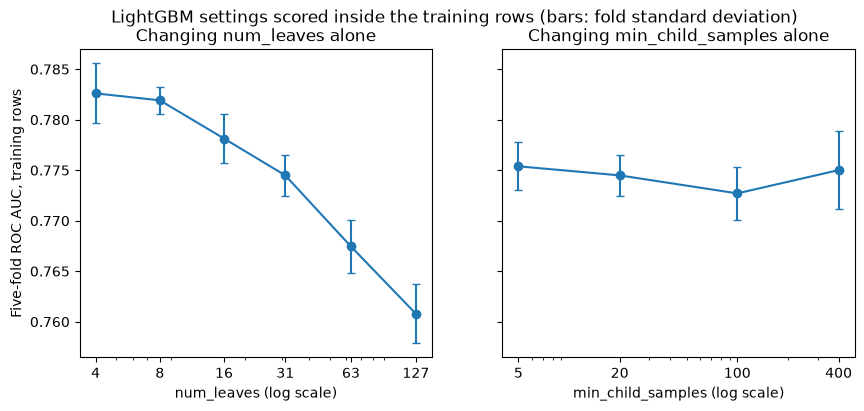

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, setting in zip(axes, ["num_leaves", "min_child_samples"]):
    part = cv_table[cv_table["setting"] == setting]
    ax.errorbar(part["value"], part["cv_mean"], yerr=part["cv_sd"], marker="o", capsize=3)
    ax.set_xscale("log")
    ax.set_xticks(part["value"])
    ax.set_xticklabels(part["value"])
    ax.set_xlabel(setting + " (log scale)")
    ax.set_title(f"Changing {setting} alone")
axes[0].set_ylabel("Five-fold ROC AUC, training rows")
fig.suptitle("LightGBM settings scored inside the training rows (bars: fold standard deviation)")
plt.show()

* The bars are one fold standard deviation either side. The `num_leaves` curve falls by more than a bar at 4 of its 5 steps; the `min_child_samples` curve stays inside about one bar. A difference smaller than a bar is not one to choose on, which is why week 3 spends a whole day on tuning without fooling yourself.

## 9.4 HistGradientBoosting: scikit-learn's Own Version

scikit-learn has its own histogram booster, `HistGradientBoostingClassifier`, built on the same two ideas: bins, and trees limited by a number of leaves. It needs no extra package and it handles missing values itself, which week 3 uses on a file that has them.

Q. Fit it with its defaults and score it on the validation rows.

In [13]:
from sklearn.ensemble import HistGradientBoostingClassifier

hist = HistGradientBoostingClassifier(random_state=SEED).fit(X_train, y_train)
proba_hist = hist.predict_proba(X_valid)[:, 1]
settings = hist.get_params()
print(f"max_bins {settings['max_bins']}, max_leaf_nodes {settings['max_leaf_nodes']}, max_iter {settings['max_iter']}")
print(f"early_stopping {settings['early_stopping']!r}: used here {hist.do_early_stopping_}, "
      f"validation_fraction {settings['validation_fraction']}; trees fitted {hist.n_iter_}")
print(f"HistGradientBoosting: validation ROC AUC {roc_auc_score(y_valid, proba_hist):.4f}, "
      f"average precision {average_precision_score(y_valid, proba_hist):.4f}")

max_bins 255, max_leaf_nodes 31, max_iter 100
early_stopping 'auto': used here True, validation_fraction 0.1; trees fitted 55
HistGradientBoosting: validation ROC AUC 0.7773, average precision 0.5439


* Its defaults mirror LightGBM's: 255 bins, 31 leaves a tree. It allows up to 100 trees, but fitted only 55.
* `early_stopping="auto"` turns early stopping on when the training rows number more than 10,000, as here: the model sets aside 10 percent of **the rows it is given** (`validation_fraction`), stops adding trees when the score on them stops improving, and uses `random_state=SEED` to pick them. The rows it stops on come from the training rows, never from the validation rows, which is day 8's rule kept by the library itself.
* Its output is the model probability of default in this file: validation ROC AUC 0.7773, average precision 0.5439.

## 9.5 Three Boosters, One Validation Set

Q. Fit XGBoost with 300 trees of depth 4, a learning rate of 0.05, and row and column sampling of 0.8, and put the three boosters and the logistic regression side by side.

In [14]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=SEED, n_jobs=1)
xgb.fit(X_train, y_train)
proba_xgb = xgb.predict_proba(X_valid)[:, 1]

outputs = {"logistic regression": proba_logistic, "LightGBM": proba_light,
           "HistGradientBoosting": proba_hist, "XGBoost": proba_xgb}
board = pd.DataFrame({"validation ROC AUC": {name: roc_auc_score(y_valid, p) for name, p in outputs.items()},
                      "average precision": {name: average_precision_score(y_valid, p) for name, p in outputs.items()}})
print(board.round(4).to_string())
boosters = board.loc[["LightGBM", "HistGradientBoosting", "XGBoost"], "validation ROC AUC"]
print(f"spread among the three boosters: {boosters.max() - boosters.min():.4f} of ROC AUC")

                      validation ROC AUC  average precision
logistic regression               0.7190             0.4946
LightGBM                          0.7725             0.5434
HistGradientBoosting              0.7773             0.5439
XGBoost                           0.7794             0.5447
spread among the three boosters: 0.0069 of ROC AUC


* All three boosters rank the validation accounts between 0.7725 and 0.7794: XGBoost highest, LightGBM lowest, a spread of 0.0069. Every one of them is at least 0.0534 above Course 4's logistic regression.
* Three libraries with different trees, settings, and code land within 0.0069 of each other, a far smaller gap than the one between any booster and the straight-line model. Each was fitted with settings no one tuned for this file, so the order among them says little; day 10 measures how large a gap the noise from which 6,000 rows were scored can produce.

## 9.6 Stacking by Hand: Out-of-Fold Outputs as Columns

A **stack** has two layers. The base models (here Course 4's logistic regression and LightGBM) each give a probability for every account. A small final model, here a logistic regression, takes those probabilities as its columns and learns how to combine them.

The final model must learn from outputs the base models gave on rows **they were not fitted on**. Section 9.2 showed why: LightGBM scores its own training rows at 0.9220 and the validation rows at 0.7725. A final model fitted on in-sample outputs would learn to trust LightGBM for a sharpness it only has on rows it has already seen. The fix is cross-validation: split the training rows in five, fit each base model on four fifths, and keep its output on the fifth it did not see. Every training row then has an **out-of-fold** output from each base model.

Q. Add `stack_inputs` to `ensemblekit.py`. Read the docstring first.

In [15]:
%%writefile -a ensemblekit.py


def stack_inputs(models: dict, X, y, cv=None) -> pd.DataFrame:
    """The columns a stack's final model is fitted on: each base model's out-of-fold class-1 probability.

    Inputs: models, {name: classifier with predict_proba}; X, y, the training rows; cv, a splitter (default
    mlkit.cv_folds()).
    Output: a DataFrame with X's row labels and one column per model, in the order of models: each row's
    probability from the fold model that did not see it (cross_val_predict, n_jobs=1).
    Convention: what StackingClassifier(stack_method="predict_proba", cv=cv) feeds its final estimator for two
    classes. A final model fitted on in-sample outputs would learn to trust the base models too much.
    Raises ValueError if models is empty.
    """
    if not models:
        raise ValueError("models is empty")
    folds = cv if cv is not None else mlkit.cv_folds()
    columns = {name: cross_val_predict(model, X, y, cv=folds, method="predict_proba", n_jobs=1)[:, 1]
               for name, model in models.items()}
    return pd.DataFrame(columns, index=X.index)

Appending to ensemblekit.py


* `cross_val_predict` does the five fits and returns, for each row, the output of the fold model that did not see it. `method="predict_proba"` asks for probabilities, and `[:, 1]` keeps the probability of class 1, default.
* It fits clones of each model, so the models passed in are not changed. `n_jobs=1` is written out, as on every cross-validation call.

Q. Add three tests: the columns equal `cross_val_predict` within 1e-12, the columns are named and indexed as promised, and `StackingClassifier`'s final model equals a logistic regression fitted on `stack_inputs`.

In [16]:
%%writefile -a test_ensemblekit.py


from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import cross_val_predict


def base_models() -> dict:
    return {"logistic": Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))]),
            "tree": DecisionTreeClassifier(max_depth=3, random_state=SEED)}


def test_stack_inputs_match_cross_val_predict():
    X, y = card_small()
    inputs = ensemblekit.stack_inputs(base_models(), X, y)
    for name, model in base_models().items():
        direct = cross_val_predict(model, X, y, cv=ensemblekit.mlkit.cv_folds(), method="predict_proba", n_jobs=1)
        assert inputs[name].to_numpy() == pytest.approx(direct[:, 1], abs=1e-12)


def test_stack_inputs_columns_named():
    X, y = card_small(1_000)
    inputs = ensemblekit.stack_inputs(base_models(), X, y)
    assert list(inputs.columns) == ["logistic", "tree"]
    assert inputs.index.equals(X.index)
    with pytest.raises(ValueError):
        ensemblekit.stack_inputs({}, X, y)


def test_stacking_classifier_uses_out_of_fold():
    X, y = card_small()
    stack = StackingClassifier(list(base_models().items()), final_estimator=LogisticRegression(),
                               stack_method="predict_proba", cv=ensemblekit.mlkit.cv_folds(), n_jobs=1).fit(X, y)
    inputs = ensemblekit.stack_inputs(base_models(), X, y)
    by_hand = LogisticRegression().fit(inputs.to_numpy(), y)
    assert stack.final_estimator_.coef_ == pytest.approx(by_hand.coef_, abs=1e-10)
    assert stack.final_estimator_.intercept_ == pytest.approx(by_hand.intercept_, abs=1e-10)

Appending to test_ensemblekit.py


* The tests fit on `card_small()`, the first 3,000 training rows, and use a depth-3 tree in place of LightGBM, so the whole file stays fast.

Q. Reload the module and run the tests.

In [17]:
importlib.reload(ensemblekit)
print(f"stack_inputs in ensemblekit: {hasattr(ensemblekit, 'stack_inputs')}")

stack_inputs in ensemblekit: True


In [18]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_ensemblekit.py"],
                        cwd=work, capture_output=True, text=True)
# the run time changes from run to run, so a duration over a minute is left out of the summary line
import re
print(re.sub(r" \(\d+:\d\d:\d\d\)", "", result.stdout + result.stderr))

...................................                                      [100%]
35 passed in 11.30s



* `35 passed`: the 32 from days 1 to 8, and today's three.

Q. Build the out-of-fold columns for the logistic regression and LightGBM on the training rows.

In [19]:
# unfitted base models: stack_inputs fits its own copies, five times each
base_models = {"logistic": Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))]),
               "lightgbm": LGBMClassifier(n_estimators=300, learning_rate=0.05, random_state=SEED, n_jobs=1, verbose=-1)}
inputs = ensemblekit.stack_inputs(base_models, X_train, y_train)

print(inputs.head().round(4).to_string())
print(f"correlation of the two columns: {inputs.corr().iloc[0, 1]:.4f}")
for name in inputs:
    print(f"{name}: out-of-fold ROC AUC on the training rows {roc_auc_score(y_train, inputs[name]):.4f}")

       logistic  lightgbm
10574    0.2195    0.1781
11330    0.0855    0.0294
7127     0.0154    0.0079
25150    0.2166    0.1238
6000     0.2336    0.1399
correlation of the two columns: 0.8163
logistic: out-of-fold ROC AUC on the training rows 0.7273
lightgbm: out-of-fold ROC AUC on the training rows 0.7743


* Each row of `inputs` is one training account and each column one base model's out-of-fold model probability of default in this file. The two columns correlate at 0.8163: they agree on much of the ranking, and the final model has something to gain only where they do not.
* LightGBM's out-of-fold ROC AUC on the training rows is 0.7743, close to its 0.7725 on the validation rows and far from the in-sample 0.9220. Out-of-fold outputs are honest outputs.

Q. Fit the final logistic regression on the two columns, then apply it to the validation rows.

In [20]:
# the final model: a logistic regression on the two out-of-fold columns
layer = LogisticRegression().fit(inputs.to_numpy(), y_train)
print(f"intercept {layer.intercept_[0]:.4f}; coefficients: logistic {layer.coef_[0][0]:.4f}, lightgbm {layer.coef_[0][1]:.4f}")

# on the validation rows the base models are the ones fitted on all the training rows (section 9.2)
valid_inputs = np.column_stack([proba_logistic, proba_light])
proba_stack_hand = layer.predict_proba(valid_inputs)[:, 1]
print(f"stack by hand: validation ROC AUC {roc_auc_score(y_valid, proba_stack_hand):.4f}, "
      f"average precision {average_precision_score(y_valid, proba_stack_hand):.4f}")

intercept -2.5861; coefficients: logistic 1.1551, lightgbm 4.0365
stack by hand: validation ROC AUC 0.7718, average precision 0.5454


* The final model puts a coefficient of 4.0365 on LightGBM's column and 1.1551 on the logistic regression's, both columns on the same 0 to 1 scale: it leans mostly on LightGBM and keeps a little of the straight-line model. Its output is a model probability of default in this file, from a logistic regression whose two inputs are themselves probabilities.
* On the validation rows the base models are the ones fitted on all 18,000 training rows, and the final model applies its three numbers to their outputs. Section 9.8 compares the result.

## 9.7 StackingClassifier Does the Same

scikit-learn's `StackingClassifier` builds the same thing in one object. Given `cv=`, it makes the out-of-fold columns with that splitter, fits the final model on them, then refits every base model on all the training rows. `cv=` is always a seeded splitter in this course, never a bare number, so the folds are the same in every run.

Q. Fit `StackingClassifier` with the same base models, the same final model, and `mlkit.cv_folds()`. Does it equal the hand version?

In [21]:
from sklearn.ensemble import StackingClassifier

stack = StackingClassifier(list(base_models.items()), final_estimator=LogisticRegression(),
                           stack_method="predict_proba", cv=mlkit.cv_folds(), n_jobs=1)
stack.fit(X_train, y_train)
proba_stack = stack.predict_proba(X_valid)[:, 1]

coef_gap = np.abs(stack.final_estimator_.coef_[0] - layer.coef_[0]).max()
proba_gap = np.abs(proba_stack - proba_stack_hand).max()
print(f"final model's coefficients equal the hand version's within 1e-10: {coef_gap < 1e-10}")
print(f"validation outputs equal the hand version's within 1e-12: {proba_gap < 1e-12}")

final model's coefficients equal the hand version's within 1e-10: True
validation outputs equal the hand version's within 1e-12: True


* Both equal. `StackingClassifier` is `stack_inputs`, a logistic regression on top, and the base models refitted on all the rows, in one object. Knowing what it does inside is what lets you trust it, and spot an AI-written stack that skips the out-of-fold step (this notebook's AI check).
* `stack_method="predict_proba"` makes it pass probabilities; for two classes it passes only the class-1 column of each base model, as `stack_inputs` does.

## 9.8 Does the Stack Beat Its Best Member?

The simplest combination needs no final model at all: average the two probabilities. Put it, the stack, and both members side by side.

Q. Score the average of the two members, the stack, and both members on the validation rows.

In [22]:
# the plain average of the two members' probabilities: the simplest blend
proba_blend = (proba_logistic + proba_light) / 2

final = {"logistic regression": proba_logistic, "LightGBM": proba_light,
         "average of the two": proba_blend, "stack (logistic layer)": proba_stack}
compare = pd.DataFrame({"validation ROC AUC": {name: roc_auc_score(y_valid, p) for name, p in final.items()},
                        "average precision": {name: average_precision_score(y_valid, p) for name, p in final.items()}})
print(compare.round(4).to_string())
gap = compare.loc["stack (logistic layer)"] - compare.loc["LightGBM"]
print(f"stack minus LightGBM: ROC AUC {gap['validation ROC AUC']:+.4f}, average precision {gap['average precision']:+.4f}")

                        validation ROC AUC  average precision
logistic regression                 0.7190             0.4946
LightGBM                            0.7725             0.5434
average of the two                  0.7641             0.5354
stack (logistic layer)              0.7718             0.5454
stack minus LightGBM: ROC AUC -0.0007, average precision +0.0020


* **On ROC AUC, the stack does not beat its best member.** It ranks the validation accounts at 0.7718, 0.0007 below LightGBM alone (0.7725). On average precision it is 0.0020 above (0.5454 against 0.5434). Both gaps are in the third or fourth decimal place, and they point in opposite directions.
* The plain average does worse than LightGBM on both (0.7641, 0.5354): it gives the weaker logistic regression an equal say. The stack's final model learned from out-of-fold outputs to give LightGBM most of the weight, which is why it lands next to LightGBM rather than between the two.
* **What this shows, on these rows:** the stack wins on average precision by 0.0020 and loses on ROC AUC by 0.0007, both gaps smaller than the 0.0069 spread among three untuned boosters in section 9.5. For a difference that small, the stack adds a layer to fit and to explain. Here one member is much weaker than the other and the two columns correlate at 0.8163, so the final model has little to combine. Exercise 2 stacks two members of similar strength. Day 10 measures how large a gap the choice of validation rows alone produces.

Q. Draw every model of the day on one line.

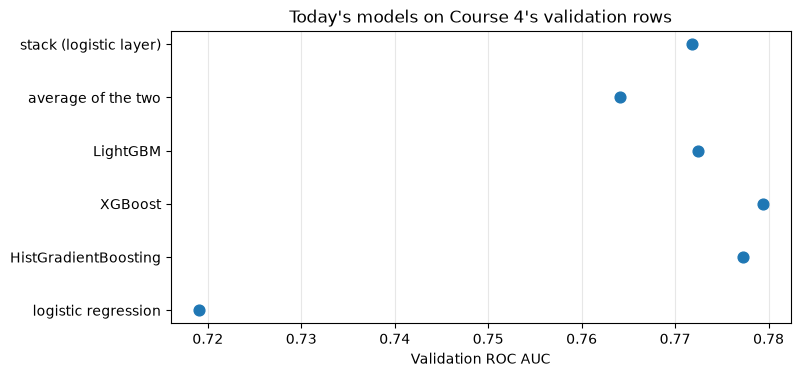

In [23]:
everything = {"logistic regression": proba_logistic, "HistGradientBoosting": proba_hist, "XGBoost": proba_xgb,
              "LightGBM": proba_light, "average of the two": proba_blend, "stack (logistic layer)": proba_stack}
fig, ax = plt.subplots(figsize=(8, 3.8))
names = list(everything)
ax.scatter([roc_auc_score(y_valid, everything[n]) for n in names], range(len(names)), s=60)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names)
ax.set_xlabel("Validation ROC AUC")
ax.set_title("Today's models on Course 4's validation rows")
ax.grid(axis="x", alpha=0.3)
plt.show()

* The three boosters and the stack sit in a tight group; the logistic regression and the plain average sit apart. The lesson of the week so far: averaging (week 1) and boosting (this week) each moved the card file a long way from Course 4's models, and combining boosters adds little on top.

## Excel Side by Side

Excel has no function for LightGBM, for gradient boosting, or for cross-validation, so neither the boosters nor the out-of-fold columns can be built on a sheet. What Excel can do is the combining: once the two members' validation probabilities are pasted in, a blend is one formula, and the stack's output is one formula from the final model's three numbers. Every formula below was typed into Excel by script (Excel 16.0 build 20430, 2026-10-05), with the logistic regression's validation probabilities in B2:B6001 and LightGBM's in C2:C6001.

| Job | Python | Excel | Excel returned |
| --- | --- | --- | --- |
| The average of two models | `(proba_logistic + proba_light) / 2` | `=AVERAGE(B2,C2)`, filled down | 0.2409 on the first account; equal to Python on all 6,000 |
| A weighted blend, weight in H6 | `w * a + (1 - w) * b` | `=$H$6*B2+(1-$H$6)*C2`, filled down | equal to Python at w = 0.3 |
| The stack's output | `stack.predict_proba(X_valid)[:, 1]` | `=1/(1+EXP(-($H$2+$H$3*B2+$H$4*C2)))`, filled down | 0.2034 on the first account; equal to Python on all 6,000 |
| Average of the blend's outputs | `proba_blend.mean()` | `=AVERAGE(D2:D6001)` | 0.2168 |
| Average of the stack's outputs | `proba_stack.mean()` | `=AVERAGE(E2:E6001)` | 0.2190 |

**The blend.** In D2 type `=AVERAGE(B2,C2)` and fill down: each account's two probabilities averaged, the Python line `(proba_logistic + proba_light) / 2`. A weighted blend puts the weight in a cell, H6, and fills `=$H$6*B2+(1-$H$6)*C2` down; the dollar signs keep every row pointing at H6. Exercise 3 writes this as a function.

**The stack.** The final model is a logistic regression with three numbers: an intercept and one coefficient per column. Paste them into H2, H3, and H4 (here -2.5861, 1.1551, 4.0365). Then `=1/(1+EXP(-($H$2+$H$3*B2+$H$4*C2)))` in E2, filled down, is the logistic function applied to the intercept plus each coefficient times its column: exactly what `predict_proba` of the final model does. The coefficients come from Python, fitted on the out-of-fold columns; Excel applies them.

Q. Do Excel's numbers equal Python's?

In [24]:
# Excel's numbers, from the course's Excel check, beside Python's for the same accounts
excel = {"average of the two, first account": 0.24087089027350717,
         "stack, first account": 0.20342877493260764,
         "average of the blend over the accounts": 0.21676094287237047,
         "average of the stack over the accounts": 0.2189739561469013}
python = {"average of the two, first account": proba_blend[0],
          "stack, first account": proba_stack[0],
          "average of the blend over the accounts": proba_blend.mean(),
          "average of the stack over the accounts": proba_stack.mean()}

side_by_side = pd.DataFrame({"Excel": excel, "Python": python})
side_by_side["within 1e-12"] = (side_by_side["Excel"] - side_by_side["Python"]).abs() < 1e-12
side_by_side

,Excel,Python,within 1e-12
"average of the two, first account",0.240871,0.240871,True
"stack, first account",0.203429,0.203429,True
average of the blend over the accounts,0.216761,0.216761,True
average of the stack over the accounts,0.218974,0.218974,True


* Every number matches within 1e-12. The stack's final model is a formula a desk can audit in a spreadsheet; the base models under it are not.

## Save the Day with Git

Q. Make the work folder a repository.

In [25]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [26]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course5_09_ysps30x6 and nowhere else


Q. Ignore the caches and Excel workbooks, then commit Course 4's module and today's two files.

In [27]:
%%writefile .gitignore
__pycache__/
.pytest_cache/
*.xlsx

Writing .gitignore


In [28]:
!git -C "{work}" add .gitignore mlkit.py ensemblekit.py test_ensemblekit.py
!git -C "{work}" commit -q -m "Add stack_inputs: out-of-fold columns for a stack's final model, 35 tests"
!git -C "{work}" log --oneline

8af8ad5 Add stack_inputs: out-of-fold columns for a stack's final model, 35 tests


Q. Write today's experiment log: each model's validation metrics, with its threshold for recall 0.70 chosen from out-of-fold probabilities on the training rows.

In [29]:
# out-of-fold thresholds: each chosen on the training rows only, by Course 4's recall rule
thresholds = {}
# LightGBM's out-of-fold column is already in inputs (same model, same folds as oof_threshold would use)
thresholds["lightgbm"] = mlkit.threshold_for_recall(y_train, inputs["lightgbm"].to_numpy(), 0.70)
thresholds["xgboost"], _ = ensemblekit.oof_threshold(
    XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
                  random_state=SEED, n_jobs=1), X_train, y_train)
# the blend's out-of-fold probability is the average of the two out-of-fold columns
thresholds["blend_logistic_lightgbm"] = mlkit.threshold_for_recall(y_train, inputs.mean(axis=1).to_numpy(), 0.70)
print({name: round(t, 4) for name, t in thresholds.items()})

{'lightgbm': 0.1778, 'xgboost': 0.1812, 'blend_logistic_lightgbm': 0.1853}


Q. The stack's threshold needs the stack's own out-of-fold probabilities: five outer folds, each fitting a whole stack with its own five inner folds. Then write the log.

In [30]:
# oof_threshold fits clones of the stack, so the fitted stack is left as it is
thresholds["stack_logistic_lightgbm"], _ = ensemblekit.oof_threshold(stack, X_train, y_train)

valid_outputs = {"lightgbm": proba_light, "xgboost": proba_xgb,
                 "blend_logistic_lightgbm": proba_blend, "stack_logistic_lightgbm": proba_stack}
rows = []
for name, output in valid_outputs.items():
    metrics = mlkit.classification_metrics(y_valid, (output >= thresholds[name]).astype(int))
    rows.append({"model": name, "rows": "validation", "roc_auc": roc_auc_score(y_valid, output),
                 "average_precision": average_precision_score(y_valid, output), "threshold": thresholds[name], **metrics})
results = pd.DataFrame(rows)
results.to_csv("results.csv", index=False, float_format="%.4f", lineterminator="\n")
print((work / "results.csv").read_text(encoding="utf-8"))
print(f"accuracy of flagging no account (all-zero baseline) on the validation rows: {1 - y_valid.mean():.4f}")

model,rows,roc_auc,average_precision,threshold,accuracy,precision,recall,f1
lightgbm,validation,0.7725,0.5434,0.1778,0.7060,0.4043,0.6956,0.5114
xgboost,validation,0.7794,0.5447,0.1812,0.7133,0.4115,0.6888,0.5152
blend_logistic_lightgbm,validation,0.7641,0.5354,0.1853,0.6987,0.3976,0.7038,0.5082
stack_logistic_lightgbm,validation,0.7718,0.5454,0.1618,0.7110,0.4103,0.7016,0.5178

accuracy of flagging no account (all-zero baseline) on the validation rows: 0.7788


* Every threshold was chosen on out-of-fold probabilities of the training rows, aiming for recall 0.70; on the validation rows the recalls come out between 0.6888 and 0.7038, close to the target, as a threshold chosen on other rows should.
* `oof_threshold` was given the fitted `stack` and fitted nothing in it: `cross_val_predict` fits clones. For the stack that means five outer folds, each with its own five inner folds for the out-of-fold columns.
* Accuracy is printed beside the all-zero baseline (0.7788) and never used to choose.

In [31]:
!git -C "{work}" add results.csv
!git -C "{work}" commit -q -m "Experiment log: LightGBM, XGBoost, a blend, and a stack on validation rows"
!git -C "{work}" log --oneline

23ab4c7 Experiment log: LightGBM, XGBoost, a blend, and a stack on validation rows
8af8ad5 Add stack_inputs: out-of-fold columns for a stack's final model, 35 tests


Q. Today's Git step: which commit wrote the line that defines `stack_inputs`?

In [32]:
# -L picks the lines from the first match of the pattern, +1 means one line; -s hides author and date
!git -C "{work}" blame -s --root -L "/def stack_inputs/,+1" ensemblekit.py

8af8ad56 350) def stack_inputs(models: dict, X, y, cv=None) -> pd.DataFrame:


* `git blame` prints, for each line, the commit that last changed it, then the line number and the line. Here the work folder has one code commit, so every line points at it; in your own `my_bondmath`, where the module grew a commit a day, the same command names the day's commit. `--root` treats the first commit like any other, and `-s` leaves out the author's name and the date.
* `-L "/def stack_inputs/,+1"` finds the line by its text, not its number, so the command keeps working as the file grows.

## Bring It Home

Add today's function to your own `my_bondmath` folder. Open a PowerShell terminal in VS Code.

**Step 1.** Go to the folder and open the two files.

```powershell
Set-Location "$HOME\projects\my_bondmath"
code ensemblekit.py
code test_ensemblekit.py
```

**Step 2.** Paste the code of today's `%%writefile -a ensemblekit.py` cell (section 9.6), without its first line, at the end of `ensemblekit.py`; do the same for the `test_ensemblekit.py` cell. Save both.

**Step 3.** Check LightGBM imports, then run the tests.

```powershell
python -c "import lightgbm; print(lightgbm.__version__)"
python -m pytest -q test_ensemblekit.py
```

The first line prints LightGBM's version. The last line of pytest says `35 passed`.

If `import lightgbm` stops with an `OSError` that names `lib_lightgbm.dll`, Windows is missing a runtime library LightGBM needs and pip does not install: the Microsoft Visual C++ Redistributable for x64, a free download from Microsoft. Install it and run the line again. The course has not tested this on a machine without that runtime.

**Step 4.** Read the change, then commit the code only.

```powershell
git diff --stat
git add ensemblekit.py test_ensemblekit.py
git commit -m "Add stack_inputs: out-of-fold columns for a stack's final model, 35 tests"
git blame -s -L "/def stack_inputs/,+1" ensemblekit.py
```

In your folder `git blame` names today's commit, because today wrote that line.

**In Colab**, download `ensemblekit.py` and `test_ensemblekit.py` from the work folder under `/tmp` in the file browser.

## You Can Now

* Say how LightGBM's trees differ from depth-limited trees (leaf-wise growth to `num_leaves`) and where its speed comes from (bins).
* Fit `LGBMClassifier` with `n_jobs=1` and `verbose=-1`, and score it on validation rows beside Course 4's logistic regression.
* Compare settings by cross-validation inside the training rows, and read a difference against the fold standard deviation.
* Fit `HistGradientBoostingClassifier` and say which rows its automatic early stopping uses.
* Build a stack's columns from out-of-fold outputs with `stack_inputs`, fit a final model on them, and show `StackingClassifier` does the same.
* Say whether a stack beat its best member, with numbers, and say so plainly when it did not.
* Reproduce a blend and a stack's output in Excel from pasted probabilities and coefficients.
* Find which commit wrote a line with `git blame -L`.

Tomorrow, day 10: a case study of boosting on the card file, and how big a gap between two models the noise of the validation rows can produce.

## Exercises

The exercises use Course 4's card rows: fitted on the 18,000 training rows, scored on the 6,000 validation rows, the test rows closed. The four person columns are not features, and every answer describes this file. Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It loads the card rows, fits Course 4's logistic regression and today's LightGBM, defines the two base models, and defines `check`, a small function that marks your answers.

In [33]:
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Course 4's training and validation rows of the card file
card = pd.read_csv("credit_card_default.csv")
X_train, X_valid, y_train, y_valid = ensemblekit.course4_card_rows(card)

# today's two base models, unfitted, and each fitted on the training rows
base_models = {"logistic": Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))]),
               "lightgbm": LGBMClassifier(n_estimators=300, learning_rate=0.05, random_state=SEED, n_jobs=1, verbose=-1)}
proba_logistic = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))]).fit(
    X_train, y_train).predict_proba(X_valid)[:, 1]
proba_light = LGBMClassifier(n_estimators=300, learning_rate=0.05, random_state=SEED, n_jobs=1, verbose=-1).fit(
    X_train, y_train).predict_proba(X_valid)[:, 1]


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")

### Exercise 1

Q. Fit today's LightGBM (300 trees, learning rate 0.05) with `class_weight="balanced"` on the training rows. Store its validation ROC AUC in **ex1_auc** and the average of its output over the validation accounts in **ex1_mean_score**. Compare the average with the validation default rate.

In [34]:
ex1_auc = ...
ex1_mean_score = ...

In [35]:
check("Exercise 1 the validation ROC AUC", ex1_auc, 0.7728768143438448)
check("Exercise 1 the average score", ex1_mean_score, 0.381899402796711)

Exercise 1 the validation ROC AUC: not attempted yet
Exercise 1 the average score: not attempted yet


### Exercise 2

Q. Stack two stronger members: a random forest (`RandomForestClassifier(n_estimators=100, min_samples_leaf=5, random_state=SEED, n_jobs=1)`) and today's LightGBM, with a logistic regression on top, `stack_method="predict_proba"`, `cv=mlkit.cv_folds()`, and `n_jobs=1`. Store the stack's validation ROC AUC in **ex2_auc**. Does it beat both members alone?

In [36]:
ex2_auc = ...

In [37]:
check("Exercise 2 the stack's validation ROC AUC", ex2_auc, 0.7811637699358708)

Exercise 2 the stack's validation ROC AUC: not attempted yet


### Exercise 3

Q. Add a function to your module. `blend(proba_a, proba_b, weight=0.5)` returns `weight * proba_a + (1 - weight) * proba_b`, and raises `ValueError` if the two lengths differ or the weight is outside 0 to 1. Write the docstring first. Then add `test_blend_hand`, which checks 0.25 of (0.2, 0.6) and 0.75 of (0.4, 0.2) gives (0.35, 0.3), and that both bad inputs raise. Run pytest, reload the module, and store the validation ROC AUC of `ensemblekit.blend(proba_logistic, proba_light, 0.3)` in **ex3_auc**.

Write the function in the cell that starts with `%%writefile -a ensemblekit.py` and the test in the one that starts with `%%writefile -a test_ensemblekit.py`, and run each of those cells once.

In [38]:
%%writefile -a ensemblekit.py


# Exercise 3: write blend(proba_a, proba_b, weight=0.5) below this line

Appending to ensemblekit.py


In [39]:
%%writefile -a test_ensemblekit.py


# Exercise 3: write test_blend_hand() below this line

Appending to test_ensemblekit.py


In [40]:
# run pytest, reload the module, then call your function
ex3_auc = ...

In [41]:
check("Exercise 3 the blend's validation ROC AUC", ex3_auc, 0.7706929174008812)

Exercise 3 the blend's validation ROC AUC: not attempted yet


### Exercise 4: AI check

You ask an AI assistant for the function that builds a stack's columns, and you give it a docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
The columns a stack's final model is fitted on.

    One column per base model, in the order of models, with X's row labels: each training row's class-1
    probability from a copy of the model that did not see that row (five folds, mlkit.cv_folds()), which is
    what StackingClassifier(stack_method="predict_proba", cv=mlkit.cv_folds()) feeds its final estimator.
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, returns one column per model with the training rows' labels, and contains one bug.

In [42]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
from sklearn.base import clone


def stack_layer_inputs(models, X, y):
    """The columns a stack's final model is fitted on.

    One column per base model, in the order of models, with X's row labels: each training row's class-1
    probability from a copy of the model that did not see that row (five folds, mlkit.cv_folds()), which is
    what StackingClassifier(stack_method="predict_proba", cv=mlkit.cv_folds()) feeds its final estimator.
    """
    columns = {}
    for name, model in models.items():
        # fit a fresh copy of each base model on the training rows and keep its probabilities for them
        fitted = clone(model).fit(X, y)
        columns[name] = fitted.predict_proba(X)[:, 1]
    return pd.DataFrame(columns, index=X.index)

Q. Before you run the next cell: if a final logistic regression is fitted on these columns, will its coefficient on LightGBM be larger or smaller than the one section 9.6 found?

In [43]:
ai_inputs = stack_layer_inputs(base_models, X_train, y_train)
ai_layer = LogisticRegression().fit(ai_inputs.to_numpy(), y_train)
print(f"columns: {list(ai_inputs.columns)}, rows: {len(ai_inputs):,}")
print(f"final model's coefficients: logistic {ai_layer.coef_[0][0]:.4f}, lightgbm {ai_layer.coef_[0][1]:.4f}")

columns: ['logistic', 'lightgbm'], rows: 18,000
final model's coefficients: logistic -6.8129, lightgbm 13.2229


Q. Test the function against its docstring before you trust it.

In [44]:
# the test, written from the docstring before the code is trusted: the columns must be out-of-fold outputs
ai_inputs = stack_layer_inputs(base_models, X_train, y_train)
honest = ensemblekit.stack_inputs(base_models, X_train, y_train)
assert list(ai_inputs.columns) == list(honest.columns) and ai_inputs.index.equals(honest.index)
gap = (ai_inputs - honest).abs().to_numpy().max()
assert gap < 1e-12, f"the columns differ from out-of-fold outputs by up to {gap:.4f}: the base models saw these rows"
print(f"stack_layer_inputs equals stack_inputs within 1e-12: {gap < 1e-12}")

AssertionError: the columns differ from out-of-fold outputs by up to 0.6284: the base models saw these rows

Q. Read the test's message, fix the function in the cell that defines it, and run that cell and the test again until the test passes. Then fit `LogisticRegression()` on the fixed function's columns and store its coefficient on the LightGBM column in **ex4_coef_lightgbm**.

In [45]:
# fix the function above and run the test again, then store the answer
ex4_coef_lightgbm = ...

In [46]:
check("Exercise 4 the coefficient on LightGBM", ex4_coef_lightgbm, 4.036495544269734)

Exercise 4 the coefficient on LightGBM: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```